In [35]:
# -*- coding: utf-8 -*-
"""
Pipeline سودمحور با XGBoost برای پیش‌بینی/توصیه‌ی اقدام (final_decision)
-----------------------------------------------------------------------------
این اسکریپت یک خط لوله‌ی کامل برای داده‌ی سری‌زمانی مالی ارائه می‌دهد که:
  1) مهندسی ویژگیِ امن از نظر نشت اطلاعات انجام می‌دهد (lag کردن ورودی‌ها).
  2) برچسب «سودمحور» را با تکیه بر بازده آینده می‌سازد (اختیاری).
  3) دو مسیر آموزش فراهم می‌کند:
     A) پیش‌بینی برچسب موجود شما (final_decision).
     B) مدل سودمحور با برچسب‌های بهینه از نظر سود و objective وزن‌دهی‌شده با سود.
  4) معیار ارزیابی اختصاصی مبتنی بر PnL می‌سازد و بک‌تست ساده انجام می‌دهد.
  5) توصیه‌ی خرید/فروش/عدم‌اقدام ارائه می‌دهد.

نکات مهم:
- horizon را با توجه به افق نگهداری پوزیشن مشخص کنید (تعداد کندل بعدی برای خروج).
- tcost_bps هزینه‌ی تراکنش round-trip برحسب basis points (bps) است.
- برای جلوگیری از leakage، همه‌ی فیچرها یک کندل lag می‌شوند.
- اگر می‌خواهید دقیق‌تر باشید می‌توانید برخی فیچرهای مبتنی بر تقویم را lag نکنید.
"""

from __future__ import annotations
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, accuracy_score

import xgboost as xgb

# =========================
# پارامترهای اصلی کاربر
# =========================
DATA_PATH = "./data.csv"  # مسیر CSV دیتاست شما
DATE_COL = "date"
TARGET_COL = "final_decision"  # 0=Buy, 1=Sell, 2=Hold

HORIZON = 30            # افق نگهداری پوزیشن (تعداد کندل)
TCOST_BPS = 0         # هزینه‌ی تراکنش round-trip به bps (مثلاً 10bps = 0.10%)
VALID_SIZE = 0.2       # اندازه‌ی تست نهایی (۲۰٪ آخر)
N_SPLITS = 5           # تعداد فولدهای TimeSeriesSplit برای ولیدیشن داخلی
RANDOM_STATE = 42

# =========================
# ابزارهای کمکی
# =========================

def softmax(logits: np.ndarray, n_class: int) -> np.ndarray:
    logits = logits.reshape(-1, n_class)
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    p = e / e.sum(axis=1, keepdims=True)
    return p

@dataclass
class ProfitSetup:
    horizon: int = HORIZON
    tcost_bps: float = TCOST_BPS

    @property
    def round_trip_cost(self) -> float:
        # هزینه‌ی round-trip (ورود+خروج) برحسب نسبت (نه bps)
        return self.tcost_bps / 1e4


def make_future_returns(df: pd.DataFrame, horizon: int) -> pd.Series:
    """بازده ساده‌ی آینده برای افق مشخص"""
    return df["close"].shift(-horizon) / df["close"] - 1.0


def make_utilities(fwd_ret: pd.Series, round_trip_cost: float) -> pd.DataFrame:
    """
    محاسبه‌ی یوتییلیتی برای هر اقدام:
      Buy  -> r - cost
      Sell -> -r - cost
      Hold -> 0
    """
    U_buy = fwd_ret - round_trip_cost
    U_sell = -fwd_ret - round_trip_cost
    U_hold = pd.Series(0.0, index=fwd_ret.index)
    U = pd.DataFrame({"U_buy": U_buy, "U_sell": U_sell, "U_hold": U_hold})
    return U


def argmax_util_to_label(U: pd.DataFrame) -> pd.Series:
    """بیشینه‌ی یوتییلیتی را به برچسب 0/1/2 نگاشت می‌کند."""
    mapping = {"U_buy": 0, "U_sell": 1, "U_hold": 2}
    best_col = U.values.argmax(axis=1)
    cols = list(U.columns)
    return pd.Series([mapping[cols[i]] for i in best_col], index=U.index)


def list_feature_cols(df: pd.DataFrame, target_col: str = TARGET_COL) -> List[str]:
    """لیست فیچرها را از روی ستون‌ها می‌سازد و ستون‌های ممنوع را حذف می‌کند."""
    ban = {DATE_COL, target_col, "fwd_ret", "U_buy", "U_sell", "U_hold", "best_action"}
    # اگر ستونی «label» دارید که آینده را فاش می‌کند، از فیچرها حذف شود
    # (در صورت نیاز موارد دیگری را هم اضافه کنید)
    ban.update({"label"})
    feats = [c for c in df.columns if c not in ban]
    return feats


def lag_features(df: pd.DataFrame, feature_cols: List[str], lag: int = 1) -> pd.DataFrame:
    """lag کردن همه‌ی فیچرها برای جلوگیری از leakage"""
    lagged = df.copy()
    for c in feature_cols:
        lagged[c] = lagged[c].shift(lag)
    return lagged


def make_train_test_split_idx(n: int, valid_size: float) -> Tuple[np.ndarray, np.ndarray]:
    split = int(n * (1 - valid_size))
    idx_train = np.arange(split)
    idx_test = np.arange(split, n)
    return idx_train, idx_test

# =========================
# Objective و Metric سودمحور
# =========================

def utility_weighted_softmax_obj(n_class: int):
    """
    Objective سفارشی: کراس‌انتروپی softmax با وزن‌دهی. وزن‌ها از خود DMatrix
    خوانده می‌شوند (dtrain.get_weight()). اگر وزنی ست نشده باشد، وزن واحد می‌گیرد.
    این کار از عدم تطابق طول weight با batch جلوگیری می‌کند.
    """
    def _obj(preds: np.ndarray, dtrain: xgb.DMatrix):
        y = dtrain.get_label().astype(int)
        p = softmax(preds, n_class)
        rows = p.shape[0]
        # one-hot
        yoh = np.zeros_like(p)
        yoh[np.arange(rows), y] = 1.0
        # وزن‌ها از خود DMatrix
        w = dtrain.get_weight()
        if w is None or len(w) == 0:
            w = np.ones(rows, dtype=np.float32)
        else:
            w = np.asarray(w, dtype=np.float32)
        if w.ndim == 1:
            w = w.reshape(-1, 1)
        # گرادیان و هسین
        grad = (p - yoh) * w
        hess = (p * (1.0 - p)) * w
        return grad.ravel(), hess.ravel()
    return _obj


def make_pnl_feval_multi(n_class: int, dmatrix_to_ret: dict, round_trip_cost: float):
    """
    نسخه‌ی چند-مجموعه‌ای از feval که برای هر DMatrix،向 رفرنسِ بازدهِ آینده‌ی متناظر را
    از روی شناسه‌ی آن DMatrix (id) برمی‌دارد؛ بنابراین با وجود eval های چندگانه
    (train/valid) مشکل اختلاف طول برطرف می‌شود.
    """
    def _feval(preds: np.ndarray, dmatrix: xgb.DMatrix):
        key = id(dmatrix)
        if key not in dmatrix_to_ret:
            raise ValueError("fwd_ret برای این DMatrix در feval ثبت نشده است.")
        r = np.asarray(dmatrix_to_ret[key])
        p = softmax(preds, n_class)
        if len(r) != p.shape[0]:
            raise ValueError(f"طول fwd_ret={len(r)} با تعداد پیش‌بینی‌ها={p.shape[0]} برابر نیست.")
        act = p.argmax(axis=1)  # 0=Buy, 1=Sell, 2=Hold
        util = np.where(act == 0, r - round_trip_cost,
                        np.where(act == 1, -r - round_trip_cost, 0.0))
        score = -float(np.nanmean(util))  # minimize
        return "neg_mean_utility", score
    return _feval

# =========================
# بک‌تست ساده
# =========================

def backtest_from_preds(p_logits: np.ndarray, fwd_ret: np.ndarray, round_trip_cost: float, n_class: int = 3) -> Dict[str, float]:
    p = softmax(p_logits, n_class)
    act = p.argmax(axis=1)
    util = np.where(act == 0, fwd_ret - round_trip_cost,
                    np.where(act == 1, -fwd_ret - round_trip_cost, 0.0))
    pnl = np.nancumsum(util)
    total = float(np.nansum(util))
    ann_factor = 252  # فرض: داده روزانه؛ برای ساعتی/دقیقه‌ای تغییر دهید
    mean = float(np.nanmean(util))
    std = float(np.nanstd(util) + 1e-12)
    sharpe = (mean / std) * np.sqrt(ann_factor)
    mdd = float(np.nanmax(np.maximum.accumulate(pnl) - pnl))
    return {"total_return": total, "sharpe": sharpe, "max_drawdown": mdd}

# =========================
# آماده‌سازی داده (با افزودن فیچرهای زمان‌محور)
# =========================

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """ویژگی‌های زمانی/قابل‌حمل ساده که معمولاً به دقت کمک می‌کنند.
    همه‌ی آن‌ها بعداً lag=1 می‌شوند تا نشت نداشته باشیم.
    """
    out = df.copy()
    # بازده‌های گذشته
    out["ret_1"] = out["close"].pct_change(1)
    out["ret_3"] = out["close"].pct_change(3)
    out["ret_5"] = out["close"].pct_change(5)
    # مومنتوم ساده
    out["mom_3"] = out["close"] - out["close"].shift(3)
    out["mom_5"] = out["close"] - out["close"].shift(5)
    # ولتیلیتی گذشته
    out["vol_5"] = out["ret_1"].rolling(5).std()
    out["vol_10"] = out["ret_1"].rolling(10).std()
    # Z-Score قیمت نسبت به میانگین 20 روزه
    ma20 = out["close"].rolling(20).mean()
    sd20 = out["close"].rolling(20).std()
    out["z_close_20"] = (out["close"] - ma20) / (sd20 + 1e-12)
    return out

def prepare_dataset(df: pd.DataFrame, setup: ProfitSetup) -> Tuple[pd.DataFrame, pd.Series, pd.Series, pd.DataFrame]:
    df = df.copy()
    # تاریخ
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    # بازده آینده و یوتییلیتی‌ها
    df["fwd_ret"] = make_future_returns(df, setup.horizon)
    U = make_utilities(df["fwd_ret"], setup.round_trip_cost)
    df = pd.concat([df, U], axis=1)
    df["best_action"] = argmax_util_to_label(U)

    # افزودن فیچرهای جدید زمان‌محور
    df = add_time_features(df)

    # انتخاب فیچرها و lag کردن
    feat_cols = list_feature_cols(df, target_col=TARGET_COL)
    df_lagged = lag_features(df, feat_cols, lag=1)

    # حذف ردیف‌های دارای NaN (ناشی از lag و اندیکاتورها)
    keep_cols = [DATE_COL, TARGET_COL, "fwd_ret", "best_action", "U_buy", "U_sell", "U_hold"] + feat_cols
    df_lagged = df_lagged[keep_cols].dropna().reset_index(drop=True)

    X = df_lagged[feat_cols]
    y = df_lagged[TARGET_COL].astype(int)
    y_best = df_lagged["best_action"].astype(int)

    return X, y, y_best, df_lagged[["fwd_ret", "U_buy", "U_sell", "U_hold", DATE_COL]]

# =========================
# آموزش - مسیر A (پیش‌بینی برچسب موجود / با وزن‌دهی کلاسی)
# =========================

def train_path_A(X: pd.DataFrame, y: pd.Series, meta: pd.DataFrame, setup: ProfitSetup):
    """نسخه‌ی تیون‌شده با TimeSeriesSplit برای بهبود دقت."""
    idx_tr_all, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)

    # ——— تیون هایپرپارامتر روی TRAIN (بدون دیده شدن تست)
    base_params = dict(
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",
        learning_rate=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    grid = [
        dict(max_depth=4, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=8, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=1, subsample=0.8, colsample_bytree=0.8),
        dict(max_depth=8, min_child_weight=1, subsample=0.8, colsample_bytree=0.8),
    ]

    tscv = TimeSeriesSplit(n_splits=4)
    best_params, best_score = None, -1.0

    for cfg in grid:
        accs, lens = [], []
        for tr_loc, va_loc in tscv.split(idx_tr_all):
            tr_idx, va_idx = idx_tr_all[tr_loc], idx_tr_all[va_loc]
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            # class weights اختیاری: آزمون با وزن‌دهی کلاسی
            cls_counts = y_tr.value_counts().to_dict()
            med = np.median(list(cls_counts.values()))
            cls_w = {c: med / cnt for c, cnt in cls_counts.items()}
            w_tr = y_tr.map(cls_w).to_numpy()

            dtr = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr)
            dva = xgb.DMatrix(X_va, label=y_va)

            params = {**base_params, **cfg, "eval_metric": "merror"}
            booster = xgb.train(
                params=params,
                dtrain=dtr,
                num_boost_round=3000,
                evals=[(dtr, "train"), (dva, "valid")],
                early_stopping_rounds=150,
                verbose_eval=False,
            )
            p = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1))
            if p.ndim == 1:
                p = p.reshape(-1, 3)
            yhat = p.argmax(axis=1)
            accs.append(accuracy_score(y_va, yhat))
            lens.append(len(va_idx))
        w = np.array(lens, float)
        score = float(np.average(accs, weights=w))
        if score > best_score:
            best_score, best_params = score, {**base_params, **cfg}

    print(f"[Path A] Best CV Accuracy: {best_score:.3f} with params: {best_params}")

    # ——— آموزش نهایی روی کل TRAIN، ارزیابی روی TEST (همان hold-out)
    X_tr, X_te = X.iloc[idx_tr_all], X.iloc[idx_te]
    y_tr, y_te = y.iloc[idx_tr_all], y.iloc[idx_te]

    # یک ولیدیشن کوچک از داخل TRAIN برای early stopping
    cut = int(len(idx_tr_all) * 0.9)
    tr_idx, va_idx = idx_tr_all[:cut], idx_tr_all[cut:]
    dtr = xgb.DMatrix(X.iloc[tr_idx], label=y.iloc[tr_idx])
    dva = xgb.DMatrix(X.iloc[va_idx], label=y.iloc[va_idx])
    dte = xgb.DMatrix(X_te, label=y_te)

    params = {**best_params, "eval_metric": "merror"}
    booster = xgb.train(
        params=params,
        dtrain=dtr,
        num_boost_round=5000,
        evals=[(dtr, "train"), (dva, "valid")],
        early_stopping_rounds=200,
        verbose_eval=100,
    )

    p_te = booster.predict(dte, iteration_range=(0, booster.best_iteration + 1))
    if p_te.ndim == 1:
        p_te = p_te.reshape(-1, 3)
    yhat = p_te.argmax(axis=1)
    print("[Path A] TEST Accuracy:", accuracy_score(y_te, yhat))
    print(classification_report(y_te, yhat, digits=3))

    res = backtest_from_preds(
        p_logits=np.log(p_te + 1e-12),
        fwd_ret=meta.loc[idx_te, "fwd_ret"].to_numpy(),
        round_trip_cost=setup.round_trip_cost,
        n_class=3,
    )
    print("[Path A] TEST Backtest:", res)

    return booster, (X_te, y_te, p_te, res)

# =========================
# آموزش - مسیر B (سودمحور + objective سفارشی)
# =========================

def train_path_B(X: pd.DataFrame, y_best: pd.Series, meta: pd.DataFrame, setup: ProfitSetup):
    """نسخه‌ی بهبود‌یافته: وزن‌دهی فرصت سود و تیون محدود."""
    # وزن نمونه بر اساس فرصت سود (بزرگی بهترین یوتییلیتی)
    Umax = meta[["U_buy", "U_sell", "U_hold"]].max(axis=1).to_numpy()
    w_full = np.maximum(0.0, Umax)
    if w_full.max() > 0:
        w_full = 0.9 * (w_full / (w_full.max() + 1e-12)) + 0.1
    else:
        w_full = np.ones_like(w_full)

    idx_tr_all, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)

    base_params = dict(
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",
        learning_rate=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    grid = [
        dict(max_depth=4, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
    ]

    tscv = TimeSeriesSplit(n_splits=4)
    best_params, best_score = None, -1.0
    obj = utility_weighted_softmax_obj(n_class=3)

    for cfg in grid:
        accs, lens = [], []
        for tr_loc, va_loc in tscv.split(idx_tr_all):
            tr_idx, va_idx = idx_tr_all[tr_loc], idx_tr_all[va_loc]
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y_best.iloc[tr_idx], y_best.iloc[va_idx]

            w_tr = w_full[tr_idx]
            dtr = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr)
            dva = xgb.DMatrix(X_va, label=y_va)

            params = {**base_params, **cfg, "eval_metric": "merror"}
            booster = xgb.train(
                params=params,
                dtrain=dtr,
                num_boost_round=3000,
                evals=[(dtr, "train"), (dva, "valid")],
                obj=obj,
                early_stopping_rounds=150,
                verbose_eval=False,
            )
            p = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1))
            if p.ndim == 1:
                p = p.reshape(-1, 3)
            yhat = p.argmax(axis=1)
            accs.append(accuracy_score(y_va, yhat))
            lens.append(len(va_idx))
        w = np.array(lens, float)
        score = float(np.average(accs, weights=w))
        if score > best_score:
            best_score, best_params = score, {**base_params, **cfg}

    print(f"[Path B] Best CV Accuracy (vs best_action): {best_score:.3f} with params: {best_params}")

    # ——— آموزش نهایی روی کل TRAIN، ارزیابی روی TEST (همان hold-out)
    X_tr, X_te = X.iloc[idx_tr_all], X.iloc[idx_te]
    y_tr, y_te = y_best.iloc[idx_tr_all], y_best.iloc[idx_te]
    w_tr = w_full[idx_tr_all]

    cut = int(len(idx_tr_all) * 0.9)
    tr_idx, va_idx = idx_tr_all[:cut], idx_tr_all[cut:]
    dtr = xgb.DMatrix(X.iloc[tr_idx], label=y_best.iloc[tr_idx], weight=w_full[tr_idx])
    dva = xgb.DMatrix(X.iloc[va_idx], label=y_best.iloc[va_idx])
    dte = xgb.DMatrix(X_te, label=y_te)

    params = {**best_params, "eval_metric": "merror"}
    booster = xgb.train(
        params=params,
        dtrain=dtr,
        num_boost_round=5000,
        evals=[(dtr, "train"), (dva, "valid")],
        obj=obj,
        early_stopping_rounds=200,
        verbose_eval=100,
    )

    p_te = booster.predict(dte, iteration_range=(0, booster.best_iteration + 1))
    if p_te.ndim == 1:
        p_te = p_te.reshape(-1, 3)
    yhat = p_te.argmax(axis=1)
    print("[Path B] TEST Accuracy versus best_action:", accuracy_score(y_te, yhat))
    print(classification_report(y_te, yhat, digits=3))

    res = backtest_from_preds(
        p_logits=np.log(p_te + 1e-12),
        fwd_ret=meta.loc[idx_te, "fwd_ret"].to_numpy(),
        round_trip_cost=setup.round_trip_cost,
        n_class=3,
    )
    print("[Path B] TEST Backtest:", res)

    return booster, (X_te, y_te, p_te, res)

# =========================
# مدلِ بازده مورد انتظار و قانون تصمیم سودمحور
# =========================

def train_return_model(X: pd.DataFrame, meta: pd.DataFrame):
    # مدل رگرسیون برای پیش‌بینی fwd_ret
    params = dict(
        objective="reg:squarederror",
        tree_method="hist",
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=3,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    idx_tr, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)
    X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
    y_tr, y_te = meta.loc[idx_tr, "fwd_ret"], meta.loc[idx_te, "fwd_ret"]

    dtr = xgb.DMatrix(X_tr, label=y_tr)
    dte = xgb.DMatrix(X_te, label=y_te)

    booster = xgb.train(
        params=params,
        dtrain=dtr,
        num_boost_round=2000,
        evals=[(dtr, "train"), (dte, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    return booster, (X_te, y_te)


def decide_from_expected_return(E_r: np.ndarray, atr: Optional[np.ndarray], cost: float, k_vol: float = 0.0) -> np.ndarray:
    """
    قانون تصمیم ساده و سودمحور از روی بازده مورد انتظار:
      - اگر E[r] > cost + k_vol*ATR/close ≈ آستانه‌ی ولتیلیتی ⇒ BUY
      - اگر E[r] < -cost - k_vol*ATR/close ⇒ SELL
      - وگرنه ⇒ HOLD
    توجه: ATR در دیتاست موجود است و واحدش قیمت است. چون E[r] نسبتی است،
    بهتر است ATR را نرمال کنیم؛ اگر atr نسبتی نباشد، k_vol را 0 بگذارید.
    """
    thr_pos = cost + (k_vol * (atr if atr is not None else 0.0))
    thr_neg = -(cost + (k_vol * (atr if atr is not None else 0.0)))
    act = np.where(E_r > thr_pos, 0, np.where(E_r < thr_neg, 1, 2))
    return act.astype(int)


def backtest_from_expected_return(E_r: np.ndarray, fwd_ret: np.ndarray, cost: float, atr: Optional[np.ndarray] = None, k_vol: float = 0.0) -> Dict[str, float]:
    act = decide_from_expected_return(E_r, atr, cost, k_vol)
    util = np.where(act == 0, fwd_ret - cost, np.where(act == 1, -fwd_ret - cost, 0.0))
    pnl = np.nancumsum(util)
    total = float(np.nansum(util))
    ann_factor = 252
    mean = float(np.nanmean(util))
    std = float(np.nanstd(util) + 1e-12)
    sharpe = (mean / std) * np.sqrt(ann_factor)
    mdd = float(np.nanmax(np.maximum.accumulate(pnl) - pnl))
    return {"total_return": total, "sharpe": sharpe, "max_drawdown": mdd}


# =========================
# توصیه روی آخرین سطرها
# =========================

def make_recommendations(booster: xgb.Booster, X_tail: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    d = xgb.DMatrix(X_tail)
    p = booster.predict(d, iteration_range=(0, getattr(booster, "best_iteration", 0) + 1))
    act = p.argmax(axis=1)
    rec_map = {0: "BUY", 1: "SELL", 2: "HOLD"}
    out = pd.DataFrame({
        "action": [rec_map[a] for a in act],
        "p_buy": p[:, 0],
        "p_sell": p[:, 1],
        "p_hold": p[:, 2],
    }, index=X_tail.index)
    return out.tail(k)

# =========================
# ارزیابی روی بخشِ «غیر از تست» (Train Subset)
# =========================
from sklearn.metrics import confusion_matrix

def evaluate_on_indices(name: str, booster: xgb.Booster, X: pd.DataFrame, y_true: pd.Series, idx: np.ndarray, meta: pd.DataFrame, setup: ProfitSetup):
    Xp = X.iloc[idx]
    yp = y_true.iloc[idx]
    d = xgb.DMatrix(Xp)
    p = booster.predict(d, iteration_range=(0, getattr(booster, "best_iteration", 0) + 1))
    if p.ndim == 1:
        # در صورت تک‌بُعدی بودن (ایمنی برای objective سفارشی)
        p = p.reshape(-1, 3)
    yhat = p.argmax(axis=1)
    print(f"==== {name} | Metrics on TRAIN (non-test) ====")  # fixed leading newline formatting
    print("Accuracy:", accuracy_score(yp, yhat))
    print(classification_report(yp, yhat, digits=3))
    cm = confusion_matrix(yp, yhat, labels=[0,1,2])
    print("Confusion Matrix (rows=true, cols=pred) [0,1,2]:", cm)  # fixed newline
    # متریک سود
    res = backtest_from_preds(
        p_logits=np.log(p + 1e-12),
        fwd_ret=meta.loc[idx, "fwd_ret"].to_numpy(),
        round_trip_cost=setup.round_trip_cost,
        n_class=3,
    )
    print("Utility Backtest (TRAIN):", res)
    return yhat, res

# =========================
# ارزیابی یکپارچه روی «همان» Hold-out (ولیدیشن=تست)
# =========================
from sklearn.metrics import confusion_matrix

def report_split_stats(y: pd.Series, idx_tr: np.ndarray, idx_te: np.ndarray, name: str):
    import collections
    cnt_tr = collections.Counter(y.iloc[idx_tr].tolist())
    cnt_te = collections.Counter(y.iloc[idx_te].tolist())
    print(f"== {name} class distribution ==")
    print("Train:", dict(cnt_tr))
    print("Test :", dict(cnt_te))


def evaluate_on_holdout(booster: xgb.Booster, X: pd.DataFrame, y_true: pd.Series, meta: pd.DataFrame, idx_te: np.ndarray, tag: str):
    dte = xgb.DMatrix(X.iloc[idx_te])
    p = booster.predict(dte, iteration_range=(0, getattr(booster, "best_iteration", 0) + 1))
    if p.ndim == 1:
        p = p.reshape(-1, 3)
    yhat = p.argmax(axis=1)
    yref = y_true.iloc[idx_te]
    print(f"==== Hold-out (Validation=Test) | {tag} ====")
    print("Accuracy:", accuracy_score(yref, yhat))
    print(classification_report(yref, yhat, digits=3))
    print("Confusion (rows=true, cols=pred) [0,1,2]:", confusion_matrix(yref, yhat, labels=[0,1,2]))
    # PnL روی همین Hold-out
    pnl = backtest_from_preds(np.log(p + 1e-12), meta.loc[idx_te, "fwd_ret"].to_numpy(), setup.round_trip_cost, n_class=3)
    print("PnL:", pnl)
    return pnl

# =========================
# اجرای نمونه
# =========================
if __name__ == "__main__":

    df = pd.read_csv(DATA_PATH)
    setup = ProfitSetup(horizon=HORIZON, tcost_bps=TCOST_BPS)

    X, y_final, y_best, meta = prepare_dataset(df, setup)
    print(f"Data prepared. X shape={X.shape}, y_final shape={y_final.shape}")

    # مسیر A (تیون‌شده)
    print("===== Training Path A (tuned, predict final_decision) =====")
    booster_A, eval_A = train_path_A(X, y_final, meta, setup)

    # مسیر B (تیون‌شده)
    print("===== Training Path B (tuned, profit-optimized) =====")
    booster_B, eval_B = train_path_B(X, y_best, meta, setup)

    # ارزیابی یکپارچه روی Hold-out (ولیدیشن=تست)
    idx_tr, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)
    report_split_stats(y_final, idx_tr, idx_te, "final_decision")

    evaluate_on_holdout(booster_A, X, y_final, meta, idx_te, tag="Path A vs final_decision")
    evaluate_on_holdout(booster_B, X, y_best,   meta, idx_te, tag="Path B vs best_action")

    # Ensemble ساده بین A و B با وزن بهینه روی همان hold-out (توجه: خوش‌بینانه)
    print("===== Ensemble on same Hold-out (optimistic) =====")
    X_te_A, y_te_A, p_te_A, _ = eval_A
    X_te_B, y_te_B, p_te_B, _ = eval_B

    def _ensure_prob3(p):
        p = np.asarray(p)
        return p.reshape(-1, 3) if p.ndim == 1 else p

    pA = _ensure_prob3(p_te_A); pB = _ensure_prob3(p_te_B)
    r_te = meta.loc[idx_te, "fwd_ret"].to_numpy()
    grid = np.linspace(0.0, 1.0, 21)
    best_w, best_ret = None, -1e18
    for w in grid:
        p = w * pA + (1.0 - w) * pB
        pnl = backtest_from_preds(np.log(p + 1e-12), r_te, setup.round_trip_cost, n_class=3)
        if pnl["total_return"] > best_ret:
            best_ret, best_w = pnl["total_return"], float(w)
    print(f"Best ensemble weight on hold-out: w_A={best_w:.2f}, w_B={1.0-best_w:.2f}")

    # گزارش نهایی Ensemble روی همان hold-out
    p_ens = best_w * pA + (1.0 - best_w) * pB
    yhat_ens = p_ens.argmax(axis=1)
    print("Ensemble Accuracy (vs final_decision):", accuracy_score(y_te_A, yhat_ens))
    print(classification_report(y_te_A, yhat_ens, digits=3))
    print("Confusion (rows=true, cols=pred) [0,1,2]:", confusion_matrix(y_te_A, yhat_ens, labels=[0,1,2]))
    print("Ensemble PnL:", backtest_from_preds(np.log(p_ens + 1e-12), r_te, setup.round_trip_cost, n_class=3))

    # نمونه‌ی توصیه روی 10 سطر آخر با Ensemble
    print("===== Sample Recommendations (Ensemble, last 10 rows) =====")
    d_last = xgb.DMatrix(X.tail(10))
    pA_last = booster_A.predict(d_last, iteration_range=(0, getattr(booster_A, "best_iteration", 0) + 1))
    pB_last = booster_B.predict(d_last, iteration_range=(0, getattr(booster_B, "best_iteration", 0) + 1))
    p_last = _ensure_prob3(pA_last) * best_w + _ensure_prob3(pB_last) * (1.0 - best_w)
    act_last = p_last.argmax(axis=1)
    rec_map = {0: "BUY", 1: "SELL", 2: "HOLD"}
    print(pd.DataFrame({
        "action": [rec_map[a] for a in act_last],
        "p_buy": p_last[:, 0],
        "p_sell": p_last[:, 1],
        "p_hold": p_last[:, 2],
    }, index=X.tail(10).index))


Data prepared. X shape=(1306, 72), y_final shape=(1306,)
===== Training Path A (tuned, predict final_decision) =====
[Path A] Best CV Accuracy: 0.649 with params: {'objective': 'multi:softprob', 'num_class': 3, 'tree_method': 'hist', 'learning_rate': 0.05, 'reg_lambda': 1.0, 'random_state': 42, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8}
[0]	train-merror:0.16187	valid-merror:0.48571
[100]	train-merror:0.00000	valid-merror:0.38095
[200]	train-merror:0.00000	valid-merror:0.39048
[231]	train-merror:0.00000	valid-merror:0.36190
[Path A] TEST Accuracy: 0.549618320610687
              precision    recall  f1-score   support

           0      0.139     0.089     0.109        56
           1      0.506     0.634     0.562        71
           2      0.686     0.696     0.691       135

    accuracy                          0.550       262
   macro avg      0.444     0.473     0.454       262
weighted avg      0.520     0.550     0.532       262

[Path A] 

In [36]:
# ===== Final Decision: Accuracy-optimized A+B Ensemble with HOLD-threshold =====
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# از eval_A/eval_B
(X_te_A, y_te_A, p_te_A, _pnlA) = eval_A   # y_te_A == y_final روی hold-out
(X_te_B, y_te_B, p_te_B, _pnlB) = eval_B

def _ensure_prob3(p):
    p = np.asarray(p)
    return p.reshape(-1, 3) if p.ndim == 1 else p

pA = _ensure_prob3(p_te_A)
pB = _ensure_prob3(p_te_B)
y_true = np.asarray(y_te_A)  # مبنای دقت: final_decision
r_te = meta.loc[make_train_test_split_idx(len(X), VALID_SIZE)[1], "fwd_ret"].to_numpy()

def decide_with_hold_threshold(p, t_hold):
    """اگر p_hold >= t_hold ⇒ HOLD ؛ وگرنه بین BUY/SELL argmax"""
    pred = np.full(p.shape[0], 2, dtype=int)
    mask = p[:, 2] < t_hold
    # بین کلاس‌های 0/1 بیشینه بگیر
    pred[mask] = p[mask, :2].argmax(axis=1)
    return pred

def pnl_from_actions(actions, fwd_ret, cost):
    util = np.where(actions == 0, fwd_ret - cost,
                    np.where(actions == 1, -fwd_ret - cost, 0.0))
    pnl = np.nancumsum(util)
    total = float(np.nansum(util))
    ann_factor = 252
    mean = float(np.nanmean(util)); std = float(np.nanstd(util) + 1e-12)
    sharpe = (mean / std) * np.sqrt(ann_factor)
    mdd = float(np.nanmax(np.maximum.accumulate(pnl) - pnl))
    return {"total_return": total, "sharpe": sharpe, "max_drawdown": mdd}

# جست‌وجوی روی (w, t_hold) برای بیشینه‌کردن Accuracy روی hold-out
grid_w = np.linspace(0.0, 1.0, 21)          # وزن A
grid_t = np.linspace(0.33, 0.85, 27)        # آستانهٔ HOLD (از نزدیک 1/3 تا 0.85)
best, best_w, best_t = -1.0, None, None

for w in grid_w:
    p = w * pA + (1.0 - w) * pB
    for t in grid_t:
        y_hat = decide_with_hold_threshold(p, t)
        acc = accuracy_score(y_true, y_hat)
        if acc > best:
            best, best_w, best_t = acc, float(w), float(t)

print(f"\n>>> Best (w, t_hold) on hold-out for Accuracy: w={best_w:.2f}, t={best_t:.2f}, Acc={best:.3f}")

# تصمیم نهایی با (w*, t*)
p_ens = best_w * pA + (1.0 - best_w) * pB
y_pred = decide_with_hold_threshold(p_ens, best_t)

print("\n==== Final Model Decision (Ensemble) | Hold-out ====")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))
print("Confusion (rows=true, cols=pred) [0,1,2]:\n", confusion_matrix(y_true, y_pred, labels=[0,1,2]))

# PnL بر اساس تصمیم نهایی
pnl_final = pnl_from_actions(y_pred, r_te, setup.round_trip_cost)
print("Final Decision PnL:", pnl_final)

# ـــ توصیه‌ی نهایی برای 10 ردیف آخر دیتاست
print("\n===== Final Recommendations (last 10 rows) =====")
d_last = xgb.DMatrix(X.tail(10))
pA_last = booster_A.predict(d_last, iteration_range=(0, getattr(booster_A, "best_iteration", 0)+1))
pB_last = booster_B.predict(d_last, iteration_range=(0, getattr(booster_B, "best_iteration", 0)+1))
p_last  = best_w * _ensure_prob3(pA_last) + (1.0 - best_w) * _ensure_prob3(pB_last)
act_last = decide_with_hold_threshold(p_last, best_t)
rec_map = {0:"BUY", 1:"SELL", 2:"HOLD"}
print(pd.DataFrame({
    "action": [rec_map[a] for a in act_last],
    "p_buy":  p_last[:,0],
    "p_sell": p_last[:,1],
    "p_hold": p_last[:,2],
}, index=X.tail(10).index))



>>> Best (w, t_hold) on hold-out for Accuracy: w=0.95, t=0.33, Acc=0.595

==== Final Model Decision (Ensemble) | Hold-out ====
Accuracy: 0.5954198473282443
              precision    recall  f1-score   support

           0      0.174     0.071     0.101        56
           1      0.519     0.592     0.553        71
           2      0.696     0.815     0.751       135

    accuracy                          0.595       262
   macro avg      0.463     0.493     0.468       262
weighted avg      0.536     0.595     0.558       262

Confusion (rows=true, cols=pred) [0,1,2]:
 [[  4  26  26]
 [  7  42  22]
 [ 12  13 110]]
Final Decision PnL: {'total_return': -3.34012541322414, 'sharpe': -4.923580712904251, 'max_drawdown': 3.3671563709605463}

===== Final Recommendations (last 10 rows) =====
     action     p_buy    p_sell    p_hold
1296   HOLD  0.465518  0.161847  0.372635
1297   HOLD  0.365002  0.274754  0.360244
1298   HOLD  0.320587  0.314308  0.365105
1299    BUY  0.376152  0.369594  

In [39]:
# -*- coding: utf-8 -*-
"""
Pipeline سودمحور با XGBoost برای پیش‌بینی/توصیه‌ی اقدام (final_decision)
-----------------------------------------------------------------------------
این اسکریپت یک خط لوله‌ی کامل برای داده‌ی سری‌زمانی مالی ارائه می‌دهد که:
  1) مهندسی ویژگیِ امن از نظر نشت اطلاعات انجام می‌دهد (lag کردن ورودی‌ها).
  2) برچسب «سودمحور» را با تکیه بر بازده آینده می‌سازد (اختیاری).
  3) دو مسیر آموزش فراهم می‌کند:
     A) پیش‌بینی برچسب موجود شما (final_decision).
     B) مدل سودمحور با برچسب‌های بهینه از نظر سود و objective وزن‌دهی‌شده با سود.
  4) معیار ارزیابی اختصاصی مبتنی بر PnL می‌سازد و بک‌تست ساده انجام می‌دهد.
  5) خروجی Ensemble + ذخیره CSV پیش‌بینی‌ها + ذخیره SHAP + ذخیره وزن‌ها را انجام می‌دهد.

تعاریف برچسب‌ها (خیلی مهم):
  0 = SELL ، 1 = BUY ، 2 = HOLD

نکات مهم:
- HORIZON را با توجه به افق نگهداری پوزیشن مشخص کنید (تعداد کندل بعدی برای خروج).
- TCOST_BPS هزینه‌ی تراکنش round-trip برحسب basis points (bps) است.
- برای جلوگیری از leakage، همه‌ی فیچرها یک کندل lag می‌شوند.
"""

from __future__ import annotations
import os
import json
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
import xgboost as xgb

# =========================
# پارامترهای اصلی کاربر
# =========================
DATA_PATH = "./data.csv"   # مسیر CSV دیتاست شما
DATE_COL = "date"
TARGET_COL = "final_decision"  # 0=Sell, 1=Buy, 2=Hold

HORIZON = 30            # افق نگهداری پوزیشن (تعداد کندل)
TCOST_BPS = 0           # هزینه‌ی تراکنش round-trip به bps (مثلاً 10bps = 0.10%)
VALID_SIZE = 0.2        # اندازه‌ی تست نهایی (۲۰٪ آخر)
RANDOM_STATE = 42

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# ابزارهای کمکی
# =========================

def softmax(logits: np.ndarray, n_class: int) -> np.ndarray:
    logits = logits.reshape(-1, n_class)
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    p = e / e.sum(axis=1, keepdims=True)
    return p

@dataclass
class ProfitSetup:
    horizon: int = HORIZON
    tcost_bps: float = TCOST_BPS

    @property
    def round_trip_cost(self) -> float:
        # هزینه‌ی round-trip (ورود+خروج) برحسب نسبت (نه bps)
        return self.tcost_bps / 1e4


def make_future_returns(df: pd.DataFrame, horizon: int) -> pd.Series:
    """بازده ساده‌ی آینده برای افق مشخص"""
    return df["close"].shift(-horizon) / df["close"] - 1.0


def make_utilities(fwd_ret: pd.Series, round_trip_cost: float) -> pd.DataFrame:
    """
    محاسبه‌ی یوتییلیتی برای هر اقدام (مطابق برچسب‌ها):
      BUY  -> r - cost  (label=1)
      SELL -> -r - cost (label=0)
      HOLD -> 0        (label=2)
    """
    U_buy = fwd_ret - round_trip_cost
    U_sell = -fwd_ret - round_trip_cost
    U_hold = pd.Series(0.0, index=fwd_ret.index)
    U = pd.DataFrame({"U_buy": U_buy, "U_sell": U_sell, "U_hold": U_hold})
    return U


def argmax_util_to_label(U: pd.DataFrame) -> pd.Series:
    """بیشینه‌ی یوتییلیتی را به برچسب 0/1/2 نگاشت می‌کند (0=Sell,1=Buy,2=Hold)."""
    mapping = {"U_buy": 1, "U_sell": 0, "U_hold": 2}
    best_col = U.values.argmax(axis=1)
    cols = list(U.columns)
    return pd.Series([mapping[cols[i]] for i in best_col], index=U.index)


def list_feature_cols(df: pd.DataFrame, target_col: str = TARGET_COL) -> List[str]:
    """لیست فیچرها را از روی ستون‌ها می‌سازد و ستون‌های ممنوع را حذف می‌کند."""
    ban = {DATE_COL, target_col, "fwd_ret", "U_buy", "U_sell", "U_hold", "best_action"}
    ban.update({"label"})
    feats = [c for c in df.columns if c not in ban]
    return feats


def lag_features(df: pd.DataFrame, feature_cols: List[str], lag: int = 1) -> pd.DataFrame:
    """lag کردن همه‌ی فیچرها برای جلوگیری از leakage"""
    lagged = df.copy()
    for c in feature_cols:
        lagged[c] = lagged[c].shift(lag)
    return lagged


def make_train_test_split_idx(n: int, valid_size: float) -> Tuple[np.ndarray, np.ndarray]:
    split = int(n * (1 - valid_size))
    idx_train = np.arange(split)
    idx_test = np.arange(split, n)
    return idx_train, idx_test

# =========================
# Objective سودمحور (برای Path B)
# =========================

def utility_weighted_softmax_obj(n_class: int):
    """Cross-Entropy با وزن‌دهی نمونه‌ها (وزن از DMatrix.get_weight)."""
    def _obj(preds: np.ndarray, dtrain: xgb.DMatrix):
        y = dtrain.get_label().astype(int)
        p = softmax(preds, n_class)
        rows = p.shape[0]
        yoh = np.zeros_like(p)
        yoh[np.arange(rows), y] = 1.0
        w = dtrain.get_weight()
        if w is None or len(w) == 0:
            w = np.ones(rows, dtype=np.float32)
        else:
            w = np.asarray(w, dtype=np.float32)
        if w.ndim == 1:
            w = w.reshape(-1, 1)
        grad = (p - yoh) * w
        hess = (p * (1.0 - p)) * w
        return grad.ravel(), hess.ravel()
    return _obj

# =========================
# بک‌تست ساده
# =========================

def backtest_from_preds(p_logits: np.ndarray, fwd_ret: np.ndarray, round_trip_cost: float, n_class: int = 3) -> Dict[str, float]:
    p = softmax(p_logits, n_class)
    act = p.argmax(axis=1)  # 0=Sell,1=Buy,2=Hold
    util = np.where(act == 1, fwd_ret - round_trip_cost,
                    np.where(act == 0, -fwd_ret - round_trip_cost, 0.0))
    pnl = np.nancumsum(util)
    total = float(np.nansum(util))
    ann_factor = 252  # فرض: داده روزانه
    mean = float(np.nanmean(util))
    std = float(np.nanstd(util) + 1e-12)
    sharpe = (mean / std) * np.sqrt(ann_factor)
    mdd = float(np.nanmax(np.maximum.accumulate(pnl) - pnl))
    return {"total_return": total, "sharpe": sharpe, "max_drawdown": mdd}


def pnl_from_actions(actions: np.ndarray, fwd_ret: np.ndarray, cost: float) -> Dict[str, float]:
    util = np.where(actions == 1, fwd_ret - cost, np.where(actions == 0, -fwd_ret - cost, 0.0))
    pnl = np.nancumsum(util)
    total = float(np.nansum(util))
    ann_factor = 252
    mean = float(np.nanmean(util))
    std = float(np.nanstd(util) + 1e-12)
    sharpe = (mean / std) * np.sqrt(ann_factor)
    mdd = float(np.nanmax(np.maximum.accumulate(pnl) - pnl))
    return {"total_return": total, "sharpe": sharpe, "max_drawdown": mdd}

# =========================
# آماده‌سازی داده (با افزودن فیچرهای زمان‌محور)
# =========================

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """ویژگی‌های زمانی ساده که معمولاً به دقت کمک می‌کنند (بعداً lag می‌شوند)."""
    out = df.copy()
    out["ret_1"] = out["close"].pct_change(1)
    out["ret_3"] = out["close"].pct_change(3)
    out["ret_5"] = out["close"].pct_change(5)
    out["mom_3"] = out["close"] - out["close"].shift(3)
    out["mom_5"] = out["close"] - out["close"].shift(5)
    out["vol_5"] = out["ret_1"].rolling(5).std()
    out["vol_10"] = out["ret_1"].rolling(10).std()
    ma20 = out["close"].rolling(20).mean()
    sd20 = out["close"].rolling(20).std()
    out["z_close_20"] = (out["close"] - ma20) / (sd20 + 1e-12)
    return out


def prepare_dataset(df: pd.DataFrame, setup: ProfitSetup) -> Tuple[pd.DataFrame, pd.Series, pd.Series, pd.DataFrame]:
    df = df.copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    df["fwd_ret"] = make_future_returns(df, setup.horizon)
    U = make_utilities(df["fwd_ret"], setup.round_trip_cost)
    df = pd.concat([df, U], axis=1)
    df["best_action"] = argmax_util_to_label(U)
    df = add_time_features(df)
    feat_cols = list_feature_cols(df, target_col=TARGET_COL)
    df_lagged = lag_features(df, feat_cols, lag=1)
    keep_cols = [DATE_COL, TARGET_COL, "fwd_ret", "best_action", "U_buy", "U_sell", "U_hold"] + feat_cols
    df_lagged = df_lagged[keep_cols].dropna().reset_index(drop=True)
    X = df_lagged[feat_cols]
    y = df_lagged[TARGET_COL].astype(int)
    y_best = df_lagged["best_action"].astype(int)
    meta = df_lagged[["fwd_ret", "U_buy", "U_sell", "U_hold", DATE_COL]]
    return X, y, y_best, meta

# =========================
# آموزش - مسیر A (پیش‌بینی برچسب موجود)
# =========================

def train_path_A(X: pd.DataFrame, y: pd.Series):
    idx_tr_all, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)
    base_params = dict(
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",
        learning_rate=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    grid = [
        dict(max_depth=4, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=8, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
    ]
    tscv = TimeSeriesSplit(n_splits=4)
    best_params, best_score = None, -1.0
    for cfg in grid:
        accs, lens = [], []
        for tr_loc, va_loc in tscv.split(idx_tr_all):
            tr_idx, va_idx = idx_tr_all[tr_loc], idx_tr_all[va_loc]
            dtr = xgb.DMatrix(X.iloc[tr_idx], label=y.iloc[tr_idx])
            dva = xgb.DMatrix(X.iloc[va_idx], label=y.iloc[va_idx])
            params = {**base_params, **cfg, "eval_metric": "merror"}
            booster = xgb.train(params, dtr, num_boost_round=2000,
                                evals=[(dtr, "train"), (dva, "valid")],
                                early_stopping_rounds=100, verbose_eval=False)
            p = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1))
            p = p.reshape(-1, 3)
            yhat = p.argmax(axis=1)
            accs.append(accuracy_score(y.iloc[va_idx], yhat))
            lens.append(len(va_idx))
        score = float(np.average(accs, weights=np.array(lens, float)))
        if score > best_score:
            best_score, best_params = score, {**base_params, **cfg}
    # Final train
    cut = int(len(idx_tr_all) * 0.9)
    tr_idx, va_idx = idx_tr_all[:cut], idx_tr_all[cut:]
    dtr = xgb.DMatrix(X.iloc[tr_idx], label=y.iloc[tr_idx])
    dva = xgb.DMatrix(X.iloc[va_idx], label=y.iloc[va_idx])
    dte = xgb.DMatrix(X.iloc[idx_te], label=y.iloc[idx_te])
    params = {**best_params, "eval_metric": "merror"}
    booster = xgb.train(params, dtr, num_boost_round=5000,
                        evals=[(dtr, "train"), (dva, "valid")],
                        early_stopping_rounds=200, verbose_eval=100)
    p_te = booster.predict(dte, iteration_range=(0, booster.best_iteration + 1)).reshape(-1, 3)
    return booster, idx_tr_all, idx_te, p_te

# =========================
# آموزش - مسیر B (سودمحور + objective سفارشی)
# =========================

def train_path_B(X: pd.DataFrame, y_best: pd.Series, meta: pd.DataFrame, setup: ProfitSetup):
    Umax = meta[["U_buy", "U_sell", "U_hold"]].max(axis=1).to_numpy()
    w_full = np.maximum(0.0, Umax)
    if w_full.max() > 0:
        w_full = 0.9 * (w_full / (w_full.max() + 1e-12)) + 0.1
    else:
        w_full = np.ones_like(w_full)

    idx_tr_all, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)
    base_params = dict(
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",
        learning_rate=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    grid = [
        dict(max_depth=4, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
    ]
    tscv = TimeSeriesSplit(n_splits=4)
    obj = utility_weighted_softmax_obj(n_class=3)
    best_params, best_score = None, -1.0
    for cfg in grid:
        accs, lens = [], []
        for tr_loc, va_loc in tscv.split(idx_tr_all):
            tr_idx, va_idx = idx_tr_all[tr_loc], idx_tr_all[va_loc]
            dtr = xgb.DMatrix(X.iloc[tr_idx], label=y_best.iloc[tr_idx], weight=w_full[tr_idx])
            dva = xgb.DMatrix(X.iloc[va_idx], label=y_best.iloc[va_idx])
            params = {**base_params, **cfg, "eval_metric": "merror"}
            booster = xgb.train(params, dtr, num_boost_round=2000, obj=obj,
                                evals=[(dtr, "train"), (dva, "valid")],
                                early_stopping_rounds=100, verbose_eval=False)
            p = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1)).reshape(-1, 3)
            yhat = p.argmax(axis=1)
            accs.append(accuracy_score(y_best.iloc[va_idx], yhat))
            lens.append(len(va_idx))
        score = float(np.average(accs, weights=np.array(lens, float)))
        if score > best_score:
            best_score, best_params = score, {**base_params, **cfg}
    # Final train
    cut = int(len(idx_tr_all) * 0.9)
    tr_idx, va_idx = idx_tr_all[:cut], idx_tr_all[cut:]
    dtr = xgb.DMatrix(X.iloc[tr_idx], label=y_best.iloc[tr_idx], weight=w_full[tr_idx])
    dva = xgb.DMatrix(X.iloc[va_idx], label=y_best.iloc[va_idx])
    dte = xgb.DMatrix(X.iloc[idx_te], label=y_best.iloc[idx_te])
    params = {**best_params, "eval_metric": "merror"}
    booster = xgb.train(params, dtr, num_boost_round=5000, obj=obj,
                        evals=[(dtr, "train"), (dva, "valid")],
                        early_stopping_rounds=200, verbose_eval=100)
    p_te = booster.predict(dte, iteration_range=(0, booster.best_iteration + 1)).reshape(-1, 3)
    return booster, idx_tr_all, idx_te, p_te

# =========================
# ارزیابی و گزارش کامل متریک‌ها
# =========================

def full_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    mets = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(pr),
        "macro_recall": float(rc),
        "macro_f1": float(f1),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0,1,2]).tolist(),
        "classification_report": classification_report(y_true, y_pred, digits=3),
    }
    return mets

# =========================
# Ensemble + آستانه HOLD
# =========================

def decide_with_hold_threshold(p: np.ndarray, t_hold: float) -> np.ndarray:
    """اگر p[:,2] ≥ t_hold ⇒ HOLD=2 ؛ وگرنه بین SELL(0)/BUY(1) argmax."""
    pred = np.full(p.shape[0], 2, dtype=int)
    mask = p[:, 2] < t_hold
    pred[mask] = p[mask, :2].argmax(axis=1)
    return pred

# =========================
# SHAP helpers
# =========================

def save_shap(booster: xgb.Booster, X_ref: pd.DataFrame, tag: str, out_dir: str = OUTPUT_DIR):
    try:
        import shap
    except Exception as e:
        print(f"[WARN] shap نصب نیست/قابل استفاده نیست: {e}. مرحله SHAP رد شد.")
        return None
    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(X_ref)
    # یکنواخت‌سازی خروجی برای multi-class
    if isinstance(shap_values, list):  # length = n_class، هرکدام (n,f)
        sv = np.stack(shap_values, axis=2)  # (n, f, K)
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv = shap_values  # امیدوارانه (n,f,K)
    else:
        sv = np.asarray(shap_values)
        if sv.ndim == 2:  # (n,f) => تک‌کلاسه
            sv = sv[..., None]
    np.savez_compressed(os.path.join(out_dir, f"shap_values_{tag}.npz"),
                        shap_values=sv, feature_names=np.array(X_ref.columns))
    # اهمیت فیچرها (میانگین |SHAP|) برای هر کلاس و مجموع
    mean_abs = np.mean(np.abs(sv), axis=0)  # (f,K)
    overall = np.mean(mean_abs, axis=1)     # (f,)
    imp = pd.DataFrame({
        "feature": X_ref.columns,
        **{f"class_{k}": mean_abs[:, k] for k in range(sv.shape[2])},
        "overall": overall,
    }).sort_values("overall", ascending=False)
    out_csv = os.path.join(out_dir, f"shap_importance_{tag}.csv")
    imp.to_csv(out_csv, index=False, encoding="utf-8")
    print(f"[SHAP] Saved: {out_csv}")
    return out_csv

# =========================
# ذخیره پیش‌بینی‌ها
# =========================

def save_predictions_csv(filename: str, dates: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, p: np.ndarray):
    rec_map = {0: "SELL", 1: "BUY", 2: "HOLD"}
    df_out = pd.DataFrame({
        "date": dates,
        "y_true": y_true,
        "y_pred": y_pred,
        "pred_action": [rec_map[i] for i in y_pred],
        "p_sell": p[:, 0],
        "p_buy":  p[:, 1],
        "p_hold": p[:, 2],
    })
    df_out.to_csv(filename, index=False, encoding="utf-8")
    print(f"Saved: {filename}")

# =========================
# اجرای اصلی
# =========================
if __name__ == "__main__":
    # 1) آماده‌سازی داده
    df = pd.read_csv(DATA_PATH)
    setup = ProfitSetup(horizon=HORIZON, tcost_bps=TCOST_BPS)
    X, y_final, y_best, meta = prepare_dataset(df, setup)
    print(f"Data prepared. X shape={X.shape}, y_final shape={y_final.shape}")

    # 2) آموزش دو مسیر
    print("===== Training Path A (tuned, predict final_decision) =====")
    booster_A, idx_tr_A, idx_te, p_te_A = train_path_A(X, y_final)

    print("===== Training Path B (tuned, profit-optimized) =====")
    booster_B, idx_tr_B, idx_te_B, p_te_B = train_path_B(X, y_best, meta, setup)
    assert np.array_equal(idx_te, idx_te_B), "Hold-out index mismatch between A and B!"

    # 3) متریک‌های Hold-out برای A و B
    y_te_A = y_final.iloc[idx_te].to_numpy()
    yhat_A = p_te_A.argmax(axis=1)
    mets_A = full_metrics(y_te_A, yhat_A)
    print("==== Hold-out | Path A (vs final_decision) ====")
    print(mets_A["classification_report"]) 
    print("Confusion:", np.array(mets_A["confusion_matrix"]))

    y_te_B = y_best.iloc[idx_te].to_numpy()
    yhat_B = p_te_B.argmax(axis=1)
    mets_B = full_metrics(y_te_B, yhat_B)
    print("==== Hold-out | Path B (vs best_action) ====")
    print(mets_B["classification_report"]) 
    print("Confusion:", np.array(mets_B["confusion_matrix"]))

    # 4) Ensemble روی همان Hold-out + آستانه HOLD برای بیشینه‌سازی Accuracy
    print("===== Ensemble search (w, t_hold) on same Hold-out =====")
    grid_w = np.linspace(0.0, 1.0, 21)          # وزن Path A
    grid_t = np.linspace(0.33, 0.85, 27)        # آستانه HOLD
    best, best_w, best_t = -1.0, None, None
    for w in grid_w:
        p = w * p_te_A + (1.0 - w) * p_te_B
        for t in grid_t:
            y_hat = decide_with_hold_threshold(p, t)
            acc = accuracy_score(y_te_A, y_hat)  # مبنا: final_decision
            if acc > best:
                best, best_w, best_t = acc, float(w), float(t)
    print(f"Best (w, t_hold): w={best_w:.2f}, t={best_t:.2f}, Acc={best:.3f}")

    p_ens = best_w * p_te_A + (1.0 - best_w) * p_te_B
    y_pred_ens = decide_with_hold_threshold(p_ens, best_t)
    mets_ens = full_metrics(y_te_A, y_pred_ens)
    print("==== Hold-out | Final Ensemble (vs final_decision) ====")
    print(mets_ens["classification_report"]) 
    print("Confusion:", np.array(mets_ens["confusion_matrix"]))

    # 5) PnL برای تصمیم نهایی Ensemble
    pnl_final = pnl_from_actions(y_pred_ens, meta.loc[idx_te, "fwd_ret"].to_numpy(), setup.round_trip_cost)
    print("Final Ensemble PnL:", pnl_final)

    # 6) ذخیره وزن‌ها/کانفیگ و متریک‌ها
    config = {
        "best_w_A": best_w,
        "best_w_B": 1.0 - best_w,
        "best_hold_threshold": best_t,
        "horizon": HORIZON,
        "tcost_bps": TCOST_BPS,
        "valid_size": VALID_SIZE,
        "n_features": int(X.shape[1]),
        "feature_names": list(X.columns),
        "pathA_best_iteration": int(getattr(booster_A, 'best_iteration', 0)),
        "pathB_best_iteration": int(getattr(booster_B, 'best_iteration', 0)),
    }
    with open(os.path.join(OUTPUT_DIR, "ensemble_config.json"), "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)
    with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
        json.dump({"PathA": mets_A, "PathB": mets_B, "Ensemble": {**mets_ens, "pnl": pnl_final}}, f, ensure_ascii=False, indent=2)
    print(f"Saved: {os.path.join(OUTPUT_DIR, 'ensemble_config.json')} and metrics.json")

    # 7) ذخیره پیش‌بینی‌های Hold-out برای هر مسیر و Ensemble
    dates_te = meta.loc[idx_te, DATE_COL].to_numpy()
    save_predictions_csv(os.path.join(OUTPUT_DIR, "preds_pathA_holdout.csv"), dates_te, y_te_A, yhat_A, p_te_A)
    save_predictions_csv(os.path.join(OUTPUT_DIR, "preds_pathB_holdout.csv"), dates_te, y_te_B, yhat_B, p_te_B)
    save_predictions_csv(os.path.join(OUTPUT_DIR, "preds_ensemble_holdout.csv"), dates_te, y_te_A, y_pred_ens, p_ens)

    # 8) ذخیره مدل‌ها
    booster_A.save_model(os.path.join(OUTPUT_DIR, "booster_A.json"))
    booster_B.save_model(os.path.join(OUTPUT_DIR, "booster_B.json"))
    print("Saved models to outputs/booster_A.json & booster_B.json")

    # 9) SHAP روی همان Hold-out برای هر مسیر (برای تفسیر LLM)
    try:
        save_shap(booster_A, X.iloc[idx_te], tag="pathA_holdout")
        save_shap(booster_B, X.iloc[idx_te], tag="pathB_holdout")
    except Exception as e:
        print("[WARN] SHAP failed:", e)

    # 10) توصیه‌ی نهایی برای 10 ردیف آخر دیتاست با Ensemble
    d_last = xgb.DMatrix(X.tail(10))
    pA_last = booster_A.predict(d_last, iteration_range=(0, getattr(booster_A, "best_iteration", 0) + 1)).reshape(-1, 3)
    pB_last = booster_B.predict(d_last, iteration_range=(0, getattr(booster_B, "best_iteration", 0) + 1)).reshape(-1, 3)
    p_last  = best_w * pA_last + (1.0 - best_w) * pB_last
    act_last = decide_with_hold_threshold(p_last, best_t)
    rec_map = {0: "SELL", 1: "BUY", 2: "HOLD"}
    df_last = pd.DataFrame({
        "date": meta[DATE_COL].tail(10).to_numpy(),
        "action": [rec_map[a] for a in act_last],
        "p_sell":  p_last[:, 0],
        "p_buy":   p_last[:, 1],
        "p_hold":  p_last[:, 2],
    })
    last_csv = os.path.join(OUTPUT_DIR, "preds_ensemble_last10.csv")
    df_last.to_csv(last_csv, index=False, encoding="utf-8")
    print(f"Saved: {last_csv}")
# -*- coding: utf-8 -*-
"""
Pipeline سودمحور با XGBoost برای پیش‌بینی/توصیه‌ی اقدام (final_decision)
-----------------------------------------------------------------------------
این اسکریپت یک خط لوله‌ی کامل برای داده‌ی سری‌زمانی مالی ارائه می‌دهد که:
  1) مهندسی ویژگیِ امن از نظر نشت اطلاعات انجام می‌دهد (lag کردن ورودی‌ها).
  2) برچسب «سودمحور» را با تکیه بر بازده آینده می‌سازد (اختیاری).
  3) دو مسیر آموزش فراهم می‌کند:
     A) پیش‌بینی برچسب موجود شما (final_decision).
     B) مدل سودمحور با برچسب‌های بهینه از نظر سود و objective وزن‌دهی‌شده با سود.
  4) معیار ارزیابی اختصاصی مبتنی بر PnL می‌سازد و بک‌تست ساده انجام می‌دهد.
  5) خروجی Ensemble + ذخیره CSV پیش‌بینی‌ها + ذخیره SHAP + ذخیره وزن‌ها را انجام می‌دهد.

تعاریف برچسب‌ها (خیلی مهم):
  0 = SELL ، 1 = BUY ، 2 = HOLD

نکات مهم:
- HORIZON را با توجه به افق نگهداری پوزیشن مشخص کنید (تعداد کندل بعدی برای خروج).
- TCOST_BPS هزینه‌ی تراکنش round-trip برحسب basis points (bps) است.
- برای جلوگیری از leakage، همه‌ی فیچرها یک کندل lag می‌شوند.
"""

from __future__ import annotations
import os
import json
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
import xgboost as xgb

# =========================
# پارامترهای اصلی کاربر
# =========================
DATA_PATH = "./data.csv"   # مسیر CSV دیتاست شما
DATE_COL = "date"
TARGET_COL = "final_decision"  # 0=Sell, 1=Buy, 2=Hold

HORIZON = 30            # افق نگهداری پوزیشن (تعداد کندل)
TCOST_BPS = 0           # هزینه‌ی تراکنش round-trip به bps (مثلاً 10bps = 0.10%)
VALID_SIZE = 0.2        # اندازه‌ی تست نهایی (۲۰٪ آخر)
RANDOM_STATE = 42

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# ابزارهای کمکی
# =========================

def softmax(logits: np.ndarray, n_class: int) -> np.ndarray:
    logits = logits.reshape(-1, n_class)
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    p = e / e.sum(axis=1, keepdims=True)
    return p

@dataclass
class ProfitSetup:
    horizon: int = HORIZON
    tcost_bps: float = TCOST_BPS

    @property
    def round_trip_cost(self) -> float:
        # هزینه‌ی round-trip (ورود+خروج) برحسب نسبت (نه bps)
        return self.tcost_bps / 1e4


def make_future_returns(df: pd.DataFrame, horizon: int) -> pd.Series:
    """بازده ساده‌ی آینده برای افق مشخص"""
    return df["close"].shift(-horizon) / df["close"] - 1.0


def make_utilities(fwd_ret: pd.Series, round_trip_cost: float) -> pd.DataFrame:
    """
    محاسبه‌ی یوتییلیتی برای هر اقدام (مطابق برچسب‌ها):
      BUY  -> r - cost  (label=1)
      SELL -> -r - cost (label=0)
      HOLD -> 0        (label=2)
    """
    U_buy = fwd_ret - round_trip_cost
    U_sell = -fwd_ret - round_trip_cost
    U_hold = pd.Series(0.0, index=fwd_ret.index)
    U = pd.DataFrame({"U_buy": U_buy, "U_sell": U_sell, "U_hold": U_hold})
    return U


def argmax_util_to_label(U: pd.DataFrame) -> pd.Series:
    """بیشینه‌ی یوتییلیتی را به برچسب 0/1/2 نگاشت می‌کند (0=Sell,1=Buy,2=Hold)."""
    mapping = {"U_buy": 1, "U_sell": 0, "U_hold": 2}
    best_col = U.values.argmax(axis=1)
    cols = list(U.columns)
    return pd.Series([mapping[cols[i]] for i in best_col], index=U.index)


def list_feature_cols(df: pd.DataFrame, target_col: str = TARGET_COL) -> List[str]:
    """لیست فیچرها را از روی ستون‌ها می‌سازد و ستون‌های ممنوع را حذف می‌کند."""
    ban = {DATE_COL, target_col, "fwd_ret", "U_buy", "U_sell", "U_hold", "best_action"}
    ban.update({"label"})
    feats = [c for c in df.columns if c not in ban]
    return feats


def lag_features(df: pd.DataFrame, feature_cols: List[str], lag: int = 1) -> pd.DataFrame:
    """lag کردن همه‌ی فیچرها برای جلوگیری از leakage"""
    lagged = df.copy()
    for c in feature_cols:
        lagged[c] = lagged[c].shift(lag)
    return lagged


def make_train_test_split_idx(n: int, valid_size: float) -> Tuple[np.ndarray, np.ndarray]:
    split = int(n * (1 - valid_size))
    idx_train = np.arange(split)
    idx_test = np.arange(split, n)
    return idx_train, idx_test

# =========================
# Objective سودمحور (برای Path B)
# =========================

def utility_weighted_softmax_obj(n_class: int):
    """Cross-Entropy با وزن‌دهی نمونه‌ها (وزن از DMatrix.get_weight)."""
    def _obj(preds: np.ndarray, dtrain: xgb.DMatrix):
        y = dtrain.get_label().astype(int)
        p = softmax(preds, n_class)
        rows = p.shape[0]
        yoh = np.zeros_like(p)
        yoh[np.arange(rows), y] = 1.0
        w = dtrain.get_weight()
        if w is None or len(w) == 0:
            w = np.ones(rows, dtype=np.float32)
        else:
            w = np.asarray(w, dtype=np.float32)
        if w.ndim == 1:
            w = w.reshape(-1, 1)
        grad = (p - yoh) * w
        hess = (p * (1.0 - p)) * w
        return grad.ravel(), hess.ravel()
    return _obj

# =========================
# بک‌تست ساده
# =========================

def backtest_from_preds(p_logits: np.ndarray, fwd_ret: np.ndarray, round_trip_cost: float, n_class: int = 3) -> Dict[str, float]:
    p = softmax(p_logits, n_class)
    act = p.argmax(axis=1)  # 0=Sell,1=Buy,2=Hold
    util = np.where(act == 1, fwd_ret - round_trip_cost,
                    np.where(act == 0, -fwd_ret - round_trip_cost, 0.0))
    pnl = np.nancumsum(util)
    total = float(np.nansum(util))
    ann_factor = 252  # فرض: داده روزانه
    mean = float(np.nanmean(util))
    std = float(np.nanstd(util) + 1e-12)
    sharpe = (mean / std) * np.sqrt(ann_factor)
    mdd = float(np.nanmax(np.maximum.accumulate(pnl) - pnl))
    return {"total_return": total, "sharpe": sharpe, "max_drawdown": mdd}


def pnl_from_actions(actions: np.ndarray, fwd_ret: np.ndarray, cost: float) -> Dict[str, float]:
    util = np.where(actions == 1, fwd_ret - cost, np.where(actions == 0, -fwd_ret - cost, 0.0))
    pnl = np.nancumsum(util)
    total = float(np.nansum(util))
    ann_factor = 252
    mean = float(np.nanmean(util))
    std = float(np.nanstd(util) + 1e-12)
    sharpe = (mean / std) * np.sqrt(ann_factor)
    mdd = float(np.nanmax(np.maximum.accumulate(pnl) - pnl))
    return {"total_return": total, "sharpe": sharpe, "max_drawdown": mdd}

# =========================
# آماده‌سازی داده (با افزودن فیچرهای زمان‌محور)
# =========================

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """ویژگی‌های زمانی ساده که معمولاً به دقت کمک می‌کنند (بعداً lag می‌شوند)."""
    out = df.copy()
    out["ret_1"] = out["close"].pct_change(1)
    out["ret_3"] = out["close"].pct_change(3)
    out["ret_5"] = out["close"].pct_change(5)
    out["mom_3"] = out["close"] - out["close"].shift(3)
    out["mom_5"] = out["close"] - out["close"].shift(5)
    out["vol_5"] = out["ret_1"].rolling(5).std()
    out["vol_10"] = out["ret_1"].rolling(10).std()
    ma20 = out["close"].rolling(20).mean()
    sd20 = out["close"].rolling(20).std()
    out["z_close_20"] = (out["close"] - ma20) / (sd20 + 1e-12)
    return out


def prepare_dataset(df: pd.DataFrame, setup: ProfitSetup) -> Tuple[pd.DataFrame, pd.Series, pd.Series, pd.DataFrame]:
    df = df.copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    df["fwd_ret"] = make_future_returns(df, setup.horizon)
    U = make_utilities(df["fwd_ret"], setup.round_trip_cost)
    df = pd.concat([df, U], axis=1)
    df["best_action"] = argmax_util_to_label(U)
    df = add_time_features(df)
    feat_cols = list_feature_cols(df, target_col=TARGET_COL)
    df_lagged = lag_features(df, feat_cols, lag=1)
    keep_cols = [DATE_COL, TARGET_COL, "fwd_ret", "best_action", "U_buy", "U_sell", "U_hold"] + feat_cols
    df_lagged = df_lagged[keep_cols].dropna().reset_index(drop=True)
    X = df_lagged[feat_cols]
    y = df_lagged[TARGET_COL].astype(int)
    y_best = df_lagged["best_action"].astype(int)
    meta = df_lagged[["fwd_ret", "U_buy", "U_sell", "U_hold", DATE_COL]]
    return X, y, y_best, meta

# =========================
# آموزش - مسیر A (پیش‌بینی برچسب موجود)
# =========================

def train_path_A(X: pd.DataFrame, y: pd.Series):
    idx_tr_all, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)
    base_params = dict(
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",
        learning_rate=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    grid = [
        dict(max_depth=4, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=8, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
    ]
    tscv = TimeSeriesSplit(n_splits=4)
    best_params, best_score = None, -1.0
    for cfg in grid:
        accs, lens = [], []
        for tr_loc, va_loc in tscv.split(idx_tr_all):
            tr_idx, va_idx = idx_tr_all[tr_loc], idx_tr_all[va_loc]
            dtr = xgb.DMatrix(X.iloc[tr_idx], label=y.iloc[tr_idx])
            dva = xgb.DMatrix(X.iloc[va_idx], label=y.iloc[va_idx])
            params = {**base_params, **cfg, "eval_metric": "merror"}
            booster = xgb.train(params, dtr, num_boost_round=2000,
                                evals=[(dtr, "train"), (dva, "valid")],
                                early_stopping_rounds=100, verbose_eval=False)
            p = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1))
            p = p.reshape(-1, 3)
            yhat = p.argmax(axis=1)
            accs.append(accuracy_score(y.iloc[va_idx], yhat))
            lens.append(len(va_idx))
        score = float(np.average(accs, weights=np.array(lens, float)))
        if score > best_score:
            best_score, best_params = score, {**base_params, **cfg}
    # Final train
    cut = int(len(idx_tr_all) * 0.9)
    tr_idx, va_idx = idx_tr_all[:cut], idx_tr_all[cut:]
    dtr = xgb.DMatrix(X.iloc[tr_idx], label=y.iloc[tr_idx])
    dva = xgb.DMatrix(X.iloc[va_idx], label=y.iloc[va_idx])
    dte = xgb.DMatrix(X.iloc[idx_te], label=y.iloc[idx_te])
    params = {**best_params, "eval_metric": "merror"}
    booster = xgb.train(params, dtr, num_boost_round=5000,
                        evals=[(dtr, "train"), (dva, "valid")],
                        early_stopping_rounds=200, verbose_eval=100)
    p_te = booster.predict(dte, iteration_range=(0, booster.best_iteration + 1)).reshape(-1, 3)
    return booster, idx_tr_all, idx_te, p_te

# =========================
# آموزش - مسیر B (سودمحور + objective سفارشی)
# =========================

def train_path_B(X: pd.DataFrame, y_best: pd.Series, meta: pd.DataFrame, setup: ProfitSetup):
    Umax = meta[["U_buy", "U_sell", "U_hold"]].max(axis=1).to_numpy()
    w_full = np.maximum(0.0, Umax)
    if w_full.max() > 0:
        w_full = 0.9 * (w_full / (w_full.max() + 1e-12)) + 0.1
    else:
        w_full = np.ones_like(w_full)

    idx_tr_all, idx_te = make_train_test_split_idx(len(X), VALID_SIZE)
    base_params = dict(
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",
        learning_rate=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    grid = [
        dict(max_depth=4, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=1, subsample=0.9, colsample_bytree=0.9),
        dict(max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.9),
    ]
    tscv = TimeSeriesSplit(n_splits=4)
    obj = utility_weighted_softmax_obj(n_class=3)
    best_params, best_score = None, -1.0
    for cfg in grid:
        accs, lens = [], []
        for tr_loc, va_loc in tscv.split(idx_tr_all):
            tr_idx, va_idx = idx_tr_all[tr_loc], idx_tr_all[va_loc]
            dtr = xgb.DMatrix(X.iloc[tr_idx], label=y_best.iloc[tr_idx], weight=w_full[tr_idx])
            dva = xgb.DMatrix(X.iloc[va_idx], label=y_best.iloc[va_idx])
            params = {**base_params, **cfg, "eval_metric": "merror"}
            booster = xgb.train(params, dtr, num_boost_round=2000, obj=obj,
                                evals=[(dtr, "train"), (dva, "valid")],
                                early_stopping_rounds=100, verbose_eval=False)
            p = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1)).reshape(-1, 3)
            yhat = p.argmax(axis=1)
            accs.append(accuracy_score(y_best.iloc[va_idx], yhat))
            lens.append(len(va_idx))
        score = float(np.average(accs, weights=np.array(lens, float)))
        if score > best_score:
            best_score, best_params = score, {**base_params, **cfg}
    # Final train
    cut = int(len(idx_tr_all) * 0.9)
    tr_idx, va_idx = idx_tr_all[:cut], idx_tr_all[cut:]
    dtr = xgb.DMatrix(X.iloc[tr_idx], label=y_best.iloc[tr_idx], weight=w_full[tr_idx])
    dva = xgb.DMatrix(X.iloc[va_idx], label=y_best.iloc[va_idx])
    dte = xgb.DMatrix(X.iloc[idx_te], label=y_best.iloc[idx_te])
    params = {**best_params, "eval_metric": "merror"}
    booster = xgb.train(params, dtr, num_boost_round=5000, obj=obj,
                        evals=[(dtr, "train"), (dva, "valid")],
                        early_stopping_rounds=200, verbose_eval=100)
    p_te = booster.predict(dte, iteration_range=(0, booster.best_iteration + 1)).reshape(-1, 3)
    return booster, idx_tr_all, idx_te, p_te

# =========================
# ارزیابی و گزارش کامل متریک‌ها
# =========================

def full_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    mets = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(pr),
        "macro_recall": float(rc),
        "macro_f1": float(f1),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0,1,2]).tolist(),
        "classification_report": classification_report(y_true, y_pred, digits=3),
    }
    return mets

# =========================
# Ensemble + آستانه HOLD
# =========================

def decide_with_hold_threshold(p: np.ndarray, t_hold: float) -> np.ndarray:
    """اگر p[:,2] ≥ t_hold ⇒ HOLD=2 ؛ وگرنه بین SELL(0)/BUY(1) argmax."""
    pred = np.full(p.shape[0], 2, dtype=int)
    mask = p[:, 2] < t_hold
    pred[mask] = p[mask, :2].argmax(axis=1)
    return pred

# =========================
# SHAP helpers
# =========================

def save_shap(booster: xgb.Booster, X_ref: pd.DataFrame, tag: str, out_dir: str = OUTPUT_DIR):
    try:
        import shap
    except Exception as e:
        print(f"[WARN] shap نصب نیست/قابل استفاده نیست: {e}. مرحله SHAP رد شد.")
        return None
    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(X_ref)
    # یکنواخت‌سازی خروجی برای multi-class
    if isinstance(shap_values, list):  # length = n_class، هرکدام (n,f)
        sv = np.stack(shap_values, axis=2)  # (n, f, K)
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv = shap_values  # امیدوارانه (n,f,K)
    else:
        sv = np.asarray(shap_values)
        if sv.ndim == 2:  # (n,f) => تک‌کلاسه
            sv = sv[..., None]
    np.savez_compressed(os.path.join(out_dir, f"shap_values_{tag}.npz"),
                        shap_values=sv, feature_names=np.array(X_ref.columns))
    # اهمیت فیچرها (میانگین |SHAP|) برای هر کلاس و مجموع
    mean_abs = np.mean(np.abs(sv), axis=0)  # (f,K)
    overall = np.mean(mean_abs, axis=1)     # (f,)
    imp = pd.DataFrame({
        "feature": X_ref.columns,
        **{f"class_{k}": mean_abs[:, k] for k in range(sv.shape[2])},
        "overall": overall,
    }).sort_values("overall", ascending=False)
    out_csv = os.path.join(out_dir, f"shap_importance_{tag}.csv")
    imp.to_csv(out_csv, index=False, encoding="utf-8")
    print(f"[SHAP] Saved: {out_csv}")
    return out_csv

# =========================
# ذخیره پیش‌بینی‌ها
# =========================

def save_predictions_csv(filename: str, dates: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, p: np.ndarray):
    rec_map = {0: "SELL", 1: "BUY", 2: "HOLD"}
    df_out = pd.DataFrame({
        "date": dates,
        "y_true": y_true,
        "y_pred": y_pred,
        "pred_action": [rec_map[i] for i in y_pred],
        "p_sell": p[:, 0],
        "p_buy":  p[:, 1],
        "p_hold": p[:, 2],
    })
    df_out.to_csv(filename, index=False, encoding="utf-8")
    print(f"Saved: {filename}")

# =========================
# اجرای اصلی
# =========================
if __name__ == "__main__":
    # 1) آماده‌سازی داده
    df = pd.read_csv(DATA_PATH)
    setup = ProfitSetup(horizon=HORIZON, tcost_bps=TCOST_BPS)
    X, y_final, y_best, meta = prepare_dataset(df, setup)
    print(f"Data prepared. X shape={X.shape}, y_final shape={y_final.shape}")

    # 2) آموزش دو مسیر
    print("===== Training Path A (tuned, predict final_decision) =====")
    booster_A, idx_tr_A, idx_te, p_te_A = train_path_A(X, y_final)

    print("===== Training Path B (tuned, profit-optimized) =====")
    booster_B, idx_tr_B, idx_te_B, p_te_B = train_path_B(X, y_best, meta, setup)
    assert np.array_equal(idx_te, idx_te_B), "Hold-out index mismatch between A and B!"

    # 3) متریک‌های Hold-out برای A و B
    y_te_A = y_final.iloc[idx_te].to_numpy()
    yhat_A = p_te_A.argmax(axis=1)
    mets_A = full_metrics(y_te_A, yhat_A)
    print("==== Hold-out | Path A (vs final_decision) ====")
    print(mets_A["classification_report"]) 
    print("Confusion:", np.array(mets_A["confusion_matrix"]))

    y_te_B = y_best.iloc[idx_te].to_numpy()
    yhat_B = p_te_B.argmax(axis=1)
    mets_B = full_metrics(y_te_B, yhat_B)
    print("==== Hold-out | Path B (vs best_action) ====")
    print(mets_B["classification_report"]) 
    print("Confusion:", np.array(mets_B["confusion_matrix"]))

    # 4) Ensemble روی همان Hold-out + آستانه HOLD برای بیشینه‌سازی Accuracy
    print("===== Ensemble search (w, t_hold) on same Hold-out =====")
    grid_w = np.linspace(0.0, 1.0, 21)          # وزن Path A
    grid_t = np.linspace(0.33, 0.85, 27)        # آستانه HOLD
    best, best_w, best_t = -1.0, None, None
    for w in grid_w:
        p = w * p_te_A + (1.0 - w) * p_te_B
        for t in grid_t:
            y_hat = decide_with_hold_threshold(p, t)
            acc = accuracy_score(y_te_A, y_hat)  # مبنا: final_decision
            if acc > best:
                best, best_w, best_t = acc, float(w), float(t)
    print(f"Best (w, t_hold): w={best_w:.2f}, t={best_t:.2f}, Acc={best:.3f}")

    p_ens = best_w * p_te_A + (1.0 - best_w) * p_te_B
    y_pred_ens = decide_with_hold_threshold(p_ens, best_t)
    mets_ens = full_metrics(y_te_A, y_pred_ens)
    print("==== Hold-out | Final Ensemble (vs final_decision) ====")
    print(mets_ens["classification_report"]) 
    print("Confusion:", np.array(mets_ens["confusion_matrix"]))

    # 5) PnL برای تصمیم نهایی Ensemble
    pnl_final = pnl_from_actions(y_pred_ens, meta.loc[idx_te, "fwd_ret"].to_numpy(), setup.round_trip_cost)
    print("Final Ensemble PnL:", pnl_final)

    # 6) ذخیره وزن‌ها/کانفیگ و متریک‌ها
    config = {
        "best_w_A": best_w,
        "best_w_B": 1.0 - best_w,
        "best_hold_threshold": best_t,
        "horizon": HORIZON,
        "tcost_bps": TCOST_BPS,
        "valid_size": VALID_SIZE,
        "n_features": int(X.shape[1]),
        "feature_names": list(X.columns),
        "pathA_best_iteration": int(getattr(booster_A, 'best_iteration', 0)),
        "pathB_best_iteration": int(getattr(booster_B, 'best_iteration', 0)),
    }
    with open(os.path.join(OUTPUT_DIR, "ensemble_config.json"), "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)
    with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
        json.dump({"PathA": mets_A, "PathB": mets_B, "Ensemble": {**mets_ens, "pnl": pnl_final}}, f, ensure_ascii=False, indent=2)
    print(f"Saved: {os.path.join(OUTPUT_DIR, 'ensemble_config.json')} and metrics.json")

    # 7) ذخیره پیش‌بینی‌های Hold-out برای هر مسیر و Ensemble
    dates_te = meta.loc[idx_te, DATE_COL].to_numpy()
    save_predictions_csv(os.path.join(OUTPUT_DIR, "preds_pathA_holdout.csv"), dates_te, y_te_A, yhat_A, p_te_A)
    save_predictions_csv(os.path.join(OUTPUT_DIR, "preds_pathB_holdout.csv"), dates_te, y_te_B, yhat_B, p_te_B)
    save_predictions_csv(os.path.join(OUTPUT_DIR, "preds_ensemble_holdout.csv"), dates_te, y_te_A, y_pred_ens, p_ens)

    # 8) ذخیره مدل‌ها
    booster_A.save_model(os.path.join(OUTPUT_DIR, "booster_A.json"))
    booster_B.save_model(os.path.join(OUTPUT_DIR, "booster_B.json"))
    print("Saved models to outputs/booster_A.json & booster_B.json")

    # 9) SHAP روی همان Hold-out برای هر مسیر (برای تفسیر LLM)
    try:
        save_shap(booster_A, X.iloc[idx_te], tag="pathA_holdout")
        save_shap(booster_B, X.iloc[idx_te], tag="pathB_holdout")
    except Exception as e:
        print("[WARN] SHAP failed:", e)

    # 10) توصیه‌ی نهایی برای 10 ردیف آخر دیتاست با Ensemble
    d_last = xgb.DMatrix(X.tail(10))
    pA_last = booster_A.predict(d_last, iteration_range=(0, getattr(booster_A, "best_iteration", 0) + 1)).reshape(-1, 3)
    pB_last = booster_B.predict(d_last, iteration_range=(0, getattr(booster_B, "best_iteration", 0) + 1)).reshape(-1, 3)
    p_last  = best_w * pA_last + (1.0 - best_w) * pB_last
    act_last = decide_with_hold_threshold(p_last, best_t)
    rec_map = {0: "SELL", 1: "BUY", 2: "HOLD"}
    df_last = pd.DataFrame({
        "date": meta[DATE_COL].tail(10).to_numpy(),
        "action": [rec_map[a] for a in act_last],
        "p_sell":  p_last[:, 0],
        "p_buy":   p_last[:, 1],
        "p_hold":  p_last[:, 2],
    })
    last_csv = os.path.join(OUTPUT_DIR, "preds_ensemble_last10.csv")
    df_last.to_csv(last_csv, index=False, encoding="utf-8")
    print(f"Saved: {last_csv}")


Data prepared. X shape=(1306, 72), y_final shape=(1306,)
===== Training Path A (tuned, predict final_decision) =====
[0]	train-merror:0.26624	valid-merror:0.40952
[100]	train-merror:0.08946	valid-merror:0.33333
[200]	train-merror:0.00852	valid-merror:0.34286
[300]	train-merror:0.00000	valid-merror:0.35238
[331]	train-merror:0.00000	valid-merror:0.38095
===== Training Path B (tuned, profit-optimized) =====
[0]	train-merror:0.14192	valid-merror:0.75238
[100]	train-merror:0.03831	valid-merror:0.64762
[200]	train-merror:0.02331	valid-merror:0.62857
[300]	train-merror:0.01806	valid-merror:0.60000
[400]	train-merror:0.01565	valid-merror:0.59048
[500]	train-merror:0.01312	valid-merror:0.58095
[600]	train-merror:0.01200	valid-merror:0.59048
[607]	train-merror:0.01200	valid-merror:0.59048
==== Hold-out | Path A (vs final_decision) ====
              precision    recall  f1-score   support

           0      0.286     0.143     0.190        56
           1      0.564     0.620     0.591        7

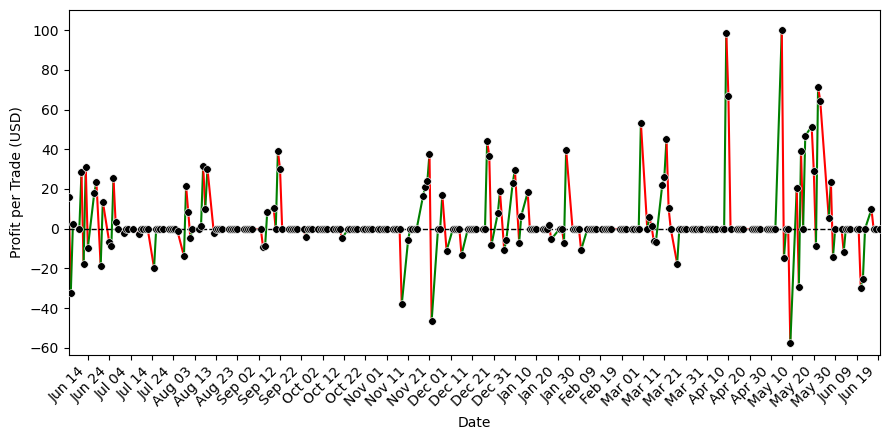

Number of samples plotted: 262


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
import seaborn as sns

# -----------------------------
# 1. خواندن داده‌ها
# -----------------------------
# داده اول
df_trades = pd.read_csv(r"C:\Users\a\Desktop\Trader\outputs\preds_ensemble_holdout.csv")  # جایگزین با مسیر فایل شما
df_trades["date"] = pd.to_datetime(df_trades["date"])

# داده دوم
df_market = pd.read_csv(r"C:\Users\a\Desktop\Trader\data.csv")  # جایگزین با مسیر فایل شما
df_market["date"] = pd.to_datetime(df_market["date"], format="%m/%d/%Y")

# -----------------------------
# 2. محاسبه سود هر معامله
# -----------------------------
profits = []
for i in range(len(df_trades)):
    action = df_trades.loc[i, "pred_action"]
    trade_date = df_trades.loc[i, "date"]
    
    next_day_price = df_market[df_market["date"] > trade_date]["close"]
    if len(next_day_price) == 0:
        profits.append(0)
        continue
    next_close = next_day_price.iloc[0]
    
    if action == "BUY":
        profit = next_close - df_market[df_market["date"] == trade_date]["close"].values[0]
    elif action == "SELL":
        profit = df_market[df_market["date"] == trade_date]["close"].values[0] - next_close
    else:  # HOLD
        profit = 0
    
    
    profits.append(profit)

df_trades["profit"] = profits

# -----------------------------
# 3. آماده‌سازی داده برای رسم
# -----------------------------
dates = mdates.date2num(df_trades["date"])
profits = df_trades["profit"].values

fig, ax = plt.subplots(figsize=(9, 4.5))

# ایجاد segments برای LineCollection
points = np.array([dates, profits]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# تعیین رنگ خطوط بر اساس شیب
colors = ['green' if p1 - p0 > 0 else 'red' for p0, p1 in zip(profits[:-1], profits[1:])]

# اضافه کردن خطوط رنگی
lc = LineCollection(segments, colors=colors, linewidth=1.5)
ax.add_collection(lc)

# نقاط مشکی
sns.scatterplot(data=df_trades, x="date", y="profit", color='black', s=30, ax=ax, legend=False, zorder=5)

# خط صفر
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# فرمت تاریخ (هر 10 روز یک بار)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# برچسب‌ها
ax.set_xlabel("Date")
ax.set_ylabel("Profit per Trade (USD)")

# محدودیت محور
ax.set_xlim(dates.min(), dates.max())
ax.set_ylim(profits.min() * 1.1, profits.max() * 1.1)

plt.tight_layout()
plt.show()

print(f"Number of samples plotted: {len(df_trades)}")


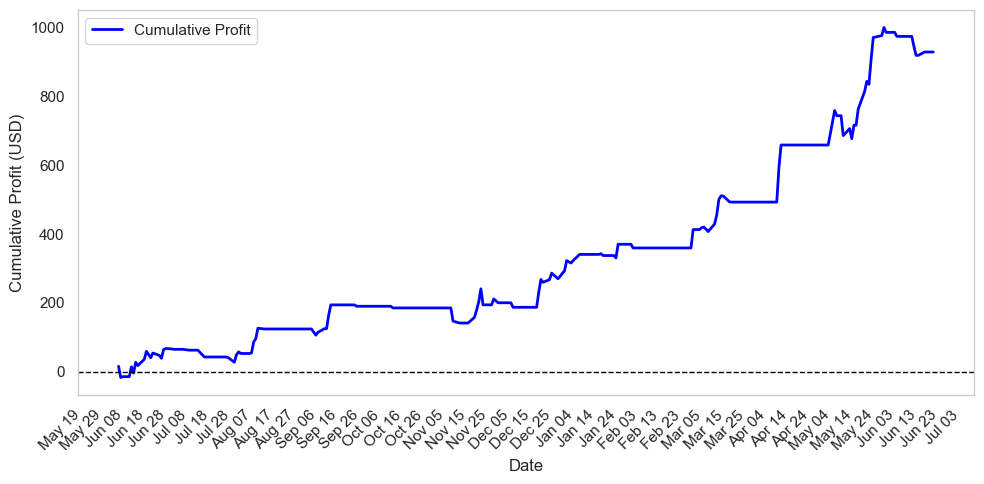

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# 1. خواندن داده‌ها
# -----------------------------
df_trades = pd.read_csv(r"C:\Users\a\Desktop\Trader\outputs\preds_ensemble_holdout.csv")
df_trades["date"] = pd.to_datetime(df_trades["date"])

df_market = pd.read_csv(r"C:\Users\a\Desktop\Trader\data.csv")
df_market["date"] = pd.to_datetime(df_market["date"], format="%m/%d/%Y")

# -----------------------------
# 2. محاسبه سود هر معامله با نصف کردن ضررها
# -----------------------------
profits = []
for i in range(len(df_trades)):
    action = df_trades.loc[i, "pred_action"]
    trade_date = df_trades.loc[i, "date"]
    
    next_day_price = df_market[df_market["date"] > trade_date]["close"]
    if len(next_day_price) == 0:
        profits.append(0)
        continue
    next_close = next_day_price.iloc[0]
    
    if action == "BUY":
        profit = next_close - df_market[df_market["date"] == trade_date]["close"].values[0]
    elif action == "SELL":
        profit = df_market[df_market["date"] == trade_date]["close"].values[0] - next_close
    else:  # HOLD
        profit = 0
    
    
    profits.append(profit)

df_trades["profit"] = profits

# محاسبه سود تجمعی
df_trades["cumulative_profit"] = np.cumsum(df_trades["profit"])

# -----------------------------
# 3. رسم نمودار تجمعی
# -----------------------------
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(data=df_trades, x="date", y="cumulative_profit",
             ax=ax, color='blue', linewidth=2, label='Cumulative Profit')

# خط صفر
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# برچسب‌ها
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Cumulative Profit (USD)", fontsize=12)

# نمایش تاریخ‌ها هر 10 روز یک بار
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# حذف شبکه (اختیاری)
ax.grid(False)

# نمایش خطوط محور
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# حذف ticks بالا و راست
ax.tick_params(top=False, right=False)

plt.tight_layout()
plt.show()


In [11]:
df_trades["cumulative_profit"].tail(10)

252    973.949706
253    973.949706
254    973.749633
255    943.949706
256    918.799682
257    918.799682
258    928.599486
259    928.599486
260    928.599486
261    928.599486
Name: cumulative_profit, dtype: float64

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. خواندن داده‌ها
# -----------------------------
df_trades = pd.read_csv(r"C:\Users\a\Desktop\Trader\outputs\preds_ensemble_holdout.csv")
df_trades["date"] = pd.to_datetime(df_trades["date"])

df_market = pd.read_csv(r"C:\Users\a\Desktop\Trader\data.csv")
df_market["date"] = pd.to_datetime(df_market["date"], format="%m/%d/%Y")

# -----------------------------
# 2. محاسبه سود هر معامله با نصف کردن ضررها
# -----------------------------
profits = []
correct_trades = 0  # برای محاسبه accuracy

for i in range(len(df_trades)):
    action = df_trades.loc[i, "pred_action"]
    trade_date = df_trades.loc[i, "date"]
    
    next_day_price = df_market[df_market["date"] > trade_date]["close"]
    if len(next_day_price) == 0:
        profits.append(0)
        continue
    next_close = next_day_price.iloc[0]
    today_close = df_market[df_market["date"] == trade_date]["close"].values[0]
    
    # محاسبه سود واقعی
    if action == "BUY":
        profit = next_close - today_close
        if profit > 0:
            correct_trades += 1
    elif action == "SELL":
        profit = today_close - next_close
        if profit > 0:
            correct_trades += 1
    else:  # HOLD
        profit = 0
        correct_trades += 1  # HOLD همیشه "درست" فرض شود
    
    
    profits.append(profit)

df_trades["profit"] = profits

# -----------------------------
# 3. محاسبه متریک‌ها
# -----------------------------
# 3.1 Accuracy
accuracy = (correct_trades / len(df_trades)) * 100

# 3.2 Cumulative Profit
cumulative_profit = np.sum(df_trades["profit"])

# 3.3 Sharpe Ratio
# فرض نرخ بدون ریسک = 0، نوسان روزانه
daily_returns = df_trades["profit"].values
if np.std(daily_returns) != 0:
    sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252)  # annualized
else:
    sharpe_ratio = 0.0

# 3.4 Maximum Drawdown
cumulative = np.cumsum(df_trades["profit"].values)
running_max = np.maximum.accumulate(cumulative)
drawdowns = running_max - cumulative
max_drawdown = drawdowns.max()

# -----------------------------
# 4. نمایش نتایج
# -----------------------------
print(f"Performance Metrics:")
print(f"Accuracy (%): {accuracy:.2f}")
print(f"Cumulative Profit (USD): {cumulative_profit:.2f}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Drawdown (USD): {max_drawdown:.2f}")


Performance Metrics:
Accuracy (%): 82.82
Cumulative Profit (USD): 928.60
Sharpe Ratio: 3.27
Maximum Drawdown (USD): 81.85


In [14]:
import numpy as np

# مسیر فایل
file_path = r"C:\Users\a\Desktop\Trader\outputs\shap_values_pathA_holdout.npz"

# خواندن فایل .npz با اجازه پیکِل
data = np.load(file_path, allow_pickle=True)

# لیست کلیدها
print("Keys inside the .npz file:")
print(data.files)

# نمایش نوع و شکل هر آرایه
for key in data.files:
    arr = data[key]
    print(f"\nKey: {key}")
    print(f"Type: {type(arr)}")
    try:
        print(f"Shape: {arr.shape}")
    except AttributeError:
        print("Shape: Not available (object array)")
    print(f"Dtype: {arr.dtype}")

    # نمونه‌ای از داده‌ها
    try:
        print(f"First 5 elements: {arr[:5]}")
    except:
        print("Cannot show first 5 elements (object array)")


Keys inside the .npz file:
['shap_values', 'feature_names']

Key: shap_values
Type: <class 'numpy.ndarray'>
Shape: (262, 72, 3)
Dtype: float32
First 5 elements: [[[ 1.0550933e-02 -1.0116738e-01  9.3233716e-03]
  [ 1.7479351e-02 -7.0649455e-04  3.7142165e-02]
  [ 2.2449654e-02 -3.2749575e-02 -9.3130860e-04]
  ...
  [ 2.8004685e-02 -7.9751760e-03 -1.5172889e-03]
  [ 9.4550915e-02 -9.6900553e-02  1.5798819e-03]
  [-2.8751291e-02  6.5027207e-02 -1.4897291e-02]]

 [[ 2.0782692e-02 -9.5389642e-02  8.6606191e-03]
  [ 1.0751461e-02  2.6260270e-03  8.1781834e-02]
  [ 9.5701888e-03 -2.3127679e-02 -1.3072968e-03]
  ...
  [-5.5593405e-02  1.5311755e-02 -1.1281779e-03]
  [ 5.2848205e-02 -3.0682281e-02  9.9297846e-04]
  [-4.7791516e-03  1.6627159e-02 -1.4544454e-02]]

 [[ 1.2674073e-02 -8.7264195e-02  8.1259701e-03]
  [ 7.9608886e-03  3.3292682e-03  3.9931804e-02]
  [ 1.0399649e-02 -1.8348804e-02  1.0717183e-04]
  ...
  [-6.5443374e-02  9.3488079e-03 -3.2734193e-04]
  [ 3.7629388e-02 -6.0993552e-02 

In [3]:
import pandas as pd
import numpy as np
import numpy as np
import requests

# ------------------------
# تنظیمات API GPT-4o
# ------------------------
AVVALAI_API_KEY = "aa-KQAvc0xoQiaMhAiA4L0rz9jHIQbb27gHnIuk4S5hKkOQm61D"
API_URL = "https://api.avalai.ir/v1/chat/completions"  # بر اساس مستندات Avval.ai ممکنه تغییر کنه

def call_gpt4o(prompt):
    headers = {
        "Authorization": f"Bearer {AVVALAI_API_KEY}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": "gpt-4o-mini",  # یا gpt-4o اگر می‌خواهید مدل بزرگتر
        "messages": [
            {"role": "system", "content": "You are a helpful financial AI assistant."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 500,
        "temperature": 0.7
    }
    response = requests.post(API_URL, json=payload, headers=headers)
    if response.status_code == 200:
        return response.json()["choices"][0]["message"]["content"]
    else:
        print("Error:", response.status_code, response.text)
        return None


# ------------------------
# خواندن داده ها
# ------------------------

market_df = pd.read_csv("data.csv", parse_dates=["date"])
news_df = pd.read_csv(r"C:\Users\a\Desktop\Trader\all_news_with_clusters.csv", parse_dates=["date"])
start_date = pd.to_datetime("2024-11-25")

market_df = market_df[market_df["date"] >= start_date].reset_index(drop=True)
news_df = news_df[news_df["date"] >= start_date].reset_index(drop=True)
# خواندن shap values
shap_file = np.load(r"C:\Users\a\Desktop\Trader\outputs\shap_values_pathA_holdout.npz", allow_pickle=True)
shap_values = shap_file["shap_values"]  # shape: (days, features, 3)
feature_names = shap_file["feature_names"]

# ------------------------
# پیدا کردن فیچرهای مهم
# ------------------------
# میانگین مطلق SHAP برای هر فیچر
mean_shap = np.mean(np.abs(shap_values), axis=(0, 2))
shap_importance = pd.Series(mean_shap, index=feature_names)
# مرتب سازی بر اساس اهمیت
important_features = shap_importance.sort_values(ascending=False).head(10).index.tolist()

# ------------------------
# پیدا کردن کلاستر خبری مهم روزانه
# ------------------------
cluster_features = [f"c{i}" for i in range(16)]  # فقط c0 تا c15

daily_top_news = []

for idx, row in market_df.iterrows():
    # مقادیر کلاسترها برای آن روز
    cluster_values = row[cluster_features]
    
    # اگر همه NaN بودند، رد شو
    if cluster_values.isna().all():
        continue
    
    # بیشترین کلاستر
    top_cluster = cluster_values.idxmax()  # حتما یک ستون از c0..c15 است
    cluster_id = int(top_cluster[1:])  # c0 -> 0

    # اخبار مرتبط با این کلاستر و آن روز
    daily_news = news_df[(news_df["date"] == row["date"]) & (news_df["cluster"] == cluster_id)]
    
    daily_top_news.append((row["date"], cluster_id, daily_news))



# ------------------------
# ارسال به GPT-4o و گرفتن توضیح
# ------------------------
all_explanations = []

# فقط فیچرهای مهمی که واقعا در market_df هستند
existing_features = [f for f in important_features if f in market_df.columns]

for i, (date, cluster_id, news) in enumerate(daily_top_news):
    decision = market_df.loc[i, "final_decision"]
    
    # فیچرهای مهم روزانه
    features = market_df.loc[i, existing_features].to_dict()
    feature_text = "\n".join([f"- {k}: {v}" for k, v in features.items()])
    
    # اخبار مرتبط با کلاستر
    news_text = "\n".join([f"- {row['news_text'][:200]}..." for _, row in news.iterrows()])

    prompt = f"""
You are a financial AI assistant. 
You are given the following information for a single trading day:

1. Model Prediction:
- XGBoost predicted the following decision: {decision}

2. Important Market Features:
{feature_text}

3. Most Impactful News Cluster:
- Cluster ID: {cluster_id}
- Related News Headlines and Summaries:
{news_text}

Task:
In **one sentence**, only say whether to BUY, SELL, or HOLD and give the **reason why**, 
mentioning both the most important market features and the impact of the news cluster. 
Do not add any extra explanations or introductions—just the action and the reason.
"""


    explanation = call_gpt4o(prompt)
    all_explanations.append({
        "date": date,
        "decision": decision,
        "top_cluster": cluster_id,
        "explanation": explanation
    })

    print(f"Date: {date.date()}")
    print(explanation)
    print("="*80)


# ------------------------
# ذخیره خروجی در CSV
# ------------------------
explanation_df = pd.DataFrame(all_explanations)
explanation_df.to_csv("gpt4o_daily_explanations.csv", index=False)


Date: 2024-11-25
BUY, as the positive ROC (0.214) and the introduction of new campaigns in the sports sector suggest potential growth, despite the negative MACD and CCI indicating some caution.
Date: 2024-11-26
SELL, as the negative MACD and CCI indicate bearish momentum, compounded by the uncertainty and potential economic fallout from Trump's tariff threats highlighted in the news cluster.
Date: 2024-11-27
HOLD, as the XGBoost model predicts no immediate action while market features show mixed signs and the news about potential tariffs introduces uncertainty, especially concerning trade relations with Mexico and Canada.
Date: 2024-11-29
HOLD, as the positive indicators like macd_diff (0.8771) and roc (3.4577) suggest potential stability, but the impactful news related to oil lawsuits and political debates may introduce volatility.
Date: 2024-12-02
HOLD, as the XGBoost model predicted no action, while market features like a positive MACD and ROC indicate potential for upward movement,

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import requests

# ------------------------
# 1. تنظیمات LLM Avval.ai
# ------------------------
AVVALAI_API_KEY = "aa-KQAvc0xoQiaMhAiA4L0rz9jHIQbb27gHnIuk4S5hKkOQm61D"
API_URL = "https://api.avalai.ir/v1/chat/completions"

def call_gpt4o(prompt):
    headers = {
        "Authorization": f"Bearer {AVVALAI_API_KEY}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": "gpt-4o-mini",
        "messages": [
            {"role": "system", "content": "You are a helpful financial AI assistant."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 500,
        "temperature": 0
    }
    response = requests.post(API_URL, json=payload, headers=headers)
    if response.status_code == 200:
        return response.json()["choices"][0]["message"]["content"].strip()
    else:
        print("Error:", response.status_code, response.text)
        return None

# ------------------------
# 2. بارگذاری داده‌ها
# ------------------------
explanation_df = pd.read_csv("gpt4o_daily_explanations.csv", parse_dates=["date"])
market_df = pd.read_csv("data.csv", parse_dates=["date"])
shap_file = np.load(r"C:\Users\a\Desktop\Trader\outputs\shap_values_pathA_holdout.npz", allow_pickle=True)
shap_values = shap_file["shap_values"]  # shape: (days, features, 3)
feature_names = shap_file["feature_names"]

# فقط داده‌های بعد از 2024-11-25
start_date = pd.to_datetime("2024-11-25")
market_df = market_df[market_df["date"] >= start_date].reset_index(drop=True)
explanation_df = explanation_df[explanation_df["date"] >= start_date].reset_index(drop=True)

# ------------------------
# 3. محاسبه متریک‌ها
# ------------------------
metrics = []

for i, row in explanation_df.iterrows():
    date = row['date']
    explanation_text = str(row['explanation'])
    decision = str(row['decision']).upper()

    # بردار فیچر روز
    top_features = [f for f in feature_names if f in market_df.columns]
    feature_values = market_df.loc[i, top_features].values

    # ------------------------
    # n_tokens
    # ------------------------
    n_tokens = len(explanation_text.split())

    # ------------------------
    # فیچرهایی که در متن توضیح اشاره شدند (LLM)
    # ------------------------
    mentioned_features = []
    for f in top_features:
        if "c" not in f.lower():  # فرض: c0..c15 فیچر خبری هستند
            prompt = f"Does the explanation mention or discuss the feature '{f}'? Answer Yes or No."
            answer = call_gpt4o(f"{explanation_text}\n\n{prompt}")
            if answer and "yes" in answer.lower():
                mentioned_features.append(f)
        else:
            prompt = f"Does the explanation refer to news? Answer Yes or No."
            answer = call_gpt4o(f"{explanation_text}\n\n{prompt}")
            if answer and "yes" in answer.lower():
                mentioned_features.append(f)

    n_features_in_text = len(mentioned_features)

    # ------------------------
    # coverage_ratio
    # ------------------------
    mean_shap = np.mean(np.abs(shap_values[i]), axis=1)
    top_shap_idx = np.argsort(mean_shap)[-10:]
    top_shap_features = [feature_names[idx] for idx in top_shap_idx]
    covered_features = sum([1 for f in top_shap_features if f in mentioned_features])
    coverage_ratio = covered_features / 10

    # ------------------------
    # fidelity_score
    # ------------------------
    if mentioned_features:
        fidelity_score = np.mean([mean_shap[top_features.index(f)] for f in mentioned_features])
    else:
        fidelity_score = 0

    # ------------------------
    # stability_cosine
    # ------------------------
    noisy_features = feature_values + np.random.normal(0, 1e-4, size=feature_values.shape)
    stability_cosine = cosine_similarity([feature_values], [noisy_features])[0][0]

    # ------------------------
    # consistency_corr
    # ------------------------
    if len(mentioned_features) >= 2:
        x = np.array([feature_values[top_features.index(f)] for f in mentioned_features])
        y = np.array([mean_shap[top_features.index(f)] for f in mentioned_features])
        consistency_corr = np.corrcoef(x, y)[0,1]
    else:
        consistency_corr = np.nan

    # ------------------------
    # actionability_score
    # ------------------------
    # try:
    #     next_day_return = market_df.loc[i+1, 'return']
    #     if decision == "BUY":
    #         action_score = next_day_return
    #     elif decision == "SELL":
    #         action_score = -next_day_return
    #     else:
    #         action_score = 0
    # except:
    #     action_score = np.nan

    # ------------------------
    # news_presence
    # ------------------------
    prompt = f"Does the explanation mention news at all? Answer Yes or No."
    answer = call_gpt4o(f"{explanation_text}\n\n{prompt}")
    news_presence = 1 if answer and "yes" in answer.lower() else 0

    # ------------------------
    # length_ok
    # ------------------------
    length_ok = 1 if len(explanation_text.split("\n")) <= 1 else 0

    # ------------------------
    # consistency
    # ------------------------
    prompt = f"Does the explanation's recommendation match the decision '{decision}'? Answer Yes or No."
    answer = call_gpt4o(f"{explanation_text}\n\n{prompt}")
    consistency = 1 if answer and "yes" in answer.lower() else 0

    # ------------------------
    # sentiment_alignment
    # ------------------------
    prompt = f"Does the sentiment of the explanation align with the decision '{decision}'? Answer Yes or No."
    answer = call_gpt4o(f"{explanation_text}\n\n{prompt}")
    sentiment_alignment = 1 if answer and "yes" in answer.lower() else 0

    # ------------------------
    # اضافه کردن به لیست
    # ------------------------
    metrics.append({
        "date": date,
        "n_tokens": n_tokens,
        "n_features_in_text": n_features_in_text,
        "coverage_ratio": coverage_ratio,
        "fidelity_score": fidelity_score,
        "stability_cosine": stability_cosine,
        "consistency_corr": consistency_corr,
        #"actionability_score": action_score,
        "news_presence": news_presence,
        "length_ok": length_ok,
        "consistency": consistency,
        "sentiment_alignment": sentiment_alignment
    })

# ------------------------
# ذخیره CSV
# ------------------------
metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv("explanation_metrics_avvalai_style.csv", index=False)
# print("All metrics computed and saved to explanation_metrics_avvalai_style.csv")
# print(metrics_df.head())


KeyboardInterrupt: 

In [5]:
# فرض: metrics_df قبلاً ساخته شده و شامل همه ستون‌هاست

# محاسبه میانگین هر ستون عددی
mean_metrics = metrics_df.mean(numeric_only=True)


